# **Trabalho 3 - Tema 5 - Agrupamento Profundo Semi-Supervisionado em Dados scRNA-seq de Câncer de Mama**

Dados de sequenciamento de RNA de célula única (single-cell RNA sequencing, ou scRNA-seq) permitem analisar a expressão gênica individualmente em cada célula de um tecido. Diferentemente de abordagens tradicionais que observam apenas médias populacionais, essa tecnologia possibilita identificar subpopulações celulares distintas, sendo particularmente relevante em estudos de câncer, onde a heterogeneidade tumoral desempenha papel importante na progressão da doença e na resposta a tratamentos.

Uma das tarefas mais comuns na análise de dados scRNA-seq é o agrupamento de células (clustering), cujo objetivo é identificar grupos de células com perfis de expressão semelhantes. Entretanto, esse problema apresenta desafios significativos devido à alta dimensionalidade dos dados, à presença de ruído biológico e técnico e à grande variabilidade entre células. Métodos clássicos, como PCA seguida de K-Means, conseguem capturar parte da estrutura dos dados, mas frequentemente apresentam limitações para representar relações mais complexas entre os diferentes tipos celulares.

Neste contexto, técnicas de aprendizado profundo têm sido utilizadas para aprender representações latentes mais compactas e informativas dos dados. Em particular, autoencoders permitem reduzir a dimensionalidade dos perfis de expressão gênica preservando características relevantes para tarefas posteriores de agrupamento. Além disso, em muitos cenários existe conhecimento biológico parcial disponível, como anotações de um pequeno subconjunto de células ou relações conhecidas entre pares de amostras. Esse conhecimento pode ser incorporado ao processo por meio de restrições do tipo must-link e cannot-link, caracterizando uma abordagem semi-supervisionada.

O objetivo deste trabalho é investigar se a utilização dessas restrições durante o aprendizado de uma representação latente é capaz de melhorar a qualidade dos agrupamentos obtidos em dados scRNA-seq de câncer de mama. Para isso, são comparados diferentes métodos de agrupamento, incluindo PCA + K-Means, COP-KMeans, autoencoder não supervisionado e um autoencoder semi-supervisionado com restrições par-a-par. A avaliação é realizada utilizando métricas de agrupamento amplamente empregadas na literatura, como NMI, ARI, Homogeneity e V-Measure, além de visualizações bidimensionais dos agrupamentos obtidos.

## 1. Preparação do ambiente

As células abaixo definem imports, caminhos e parâmetros globais. O dataset esperado está em `/content/sample_data`.

In [ ]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler


RANDOM_STATE = 42
DATA_DIR = Path("/content/sample_data")

EXPRESSION_FILE = DATA_DIR / "GSE75688_GEO_processed_Breast_Cancer_raw_TPM_matrix.txt.gz"
METADATA_FILE = DATA_DIR / "GSE75688_final_sample_information.txt.gz"

np.random.seed(RANDOM_STATE)

## 2. Funções de leitura e limpeza

O pipeline abaixo faz:

1. leitura da matriz de expressão e do metadata;
2. seleção apenas das colunas de single cells;
3. interseção entre células presentes na matriz e no metadata;
4. remoção de genes zerados ou pouco expressos;
5. seleção dos genes mais variáveis;
6. transformação `log1p`;
7. padronização com `StandardScaler`;
8. retorno de `X`, `y`, nomes das células e nomes dos genes.

Observação: por padrão, a variância e calculada sobre os valores após `log1p`, pois isso reduz o domínio de genes com TPM (Transcripts Per Million) bruto muito alto. O conjunto final retornado também passa por `log1p` antes da padronização.

In [ ]:
def make_unique(values):
    """Return unique names while preserving the original order."""
    counts = {}
    unique_values = []
    for value in values:
        value = str(value) if pd.notna(value) and str(value) else "unknown_gene"
        count = counts.get(value, 0)
        unique_values.append(value if count == 0 else f"{value}_{count}")
        counts[value] = count + 1
    return unique_values


def load_gse75688(expression_file=EXPRESSION_FILE, metadata_file=METADATA_FILE):
    metadata = pd.read_csv(metadata_file, sep="\t")
    expression = pd.read_csv(expression_file, sep="\t")

    metadata = metadata[metadata["type"].eq("SC")].set_index("sample")
    cell_columns = [sample for sample in metadata.index if sample in expression.columns]

    expression_cells = expression[cell_columns].T.copy()
    original_gene_names = expression["gene_name"].tolist()
    unique_gene_names = make_unique(original_gene_names)
    expression_cells.columns = unique_gene_names
    expression_cells = expression_cells.apply(pd.to_numeric, errors="coerce")

    common_cells = expression_cells.index.intersection(metadata.index)
    expression_cells = expression_cells.loc[common_cells].copy()
    metadata = metadata.loc[common_cells].copy()

    return expression_cells, metadata


def filter_low_expression_genes(expression_cells, min_cells=3, min_total_expression=0.0):
    expressed_in_cells = (expression_cells > 0).sum(axis=0)
    total_expression = expression_cells.sum(axis=0)

    keep_genes = (expressed_in_cells >= min_cells) & (total_expression > min_total_expression)
    return expression_cells.loc[:, keep_genes].copy()


def select_top_variable_genes(expression_cells, n_top_genes=1000, variance_after_log=True):
    matrix_for_variance = np.log1p(expression_cells) if variance_after_log else expression_cells
    variances = matrix_for_variance.var(axis=0)

    n_selected = min(n_top_genes, expression_cells.shape[1])
    selected_genes = variances.sort_values(ascending=False).head(n_selected).index.tolist()
    return expression_cells.loc[:, selected_genes].copy(), selected_genes, variances.loc[selected_genes]


def prepare_gse75688(
    n_top_genes=1000,
    min_cells=3,
    min_total_expression=0.0,
    label_column="index3",
    variance_after_log=True,
):
    expression_cells, metadata = load_gse75688()

    if label_column not in metadata.columns:
        raise ValueError(f"Column {label_column!r} not found in metadata. Available: {list(metadata.columns)}")

    valid_labels = metadata[label_column].notna()
    expression_cells = expression_cells.loc[valid_labels].copy()
    metadata = metadata.loc[valid_labels].copy()

    filtered_expression = filter_low_expression_genes(
        expression_cells,
        min_cells=min_cells,
        min_total_expression=min_total_expression,
    )
    selected_expression, gene_names, gene_variances = select_top_variable_genes(
        filtered_expression,
        n_top_genes=n_top_genes,
        variance_after_log=variance_after_log,
    )

    expression_log = np.log1p(selected_expression)
    scaler = StandardScaler()
    X = scaler.fit_transform(expression_log).astype(np.float32)

    labels = metadata[label_column].astype(str)
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(labels).astype(np.int64)

    cell_names = selected_expression.index.to_numpy()
    gene_names = np.array(gene_names)

    summary = {
        "n_cells_raw_matrix": int(expression_cells.shape[0]),
        "n_genes_raw_matrix": int(expression_cells.shape[1]),
        "n_genes_after_filter": int(filtered_expression.shape[1]),
        "n_genes_selected": int(len(gene_names)),
        "label_column": label_column,
        "classes": label_encoder.classes_.tolist(),
        "class_counts": labels.value_counts().to_dict(),
        "min_cells": min_cells,
        "min_total_expression": min_total_expression,
        "variance_after_log": variance_after_log,
    }

    return {
        "X": X,
        "y": y,
        "cell_names": cell_names,
        "gene_names": gene_names,
        "labels": labels.to_numpy(),
        "metadata": metadata,
        "selected_expression_raw": selected_expression,
        "selected_expression_log": expression_log,
        "gene_variances": gene_variances,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "summary": summary,
    }

## 3. Execução do pipeline

A configuração inicial usa os 1000 genes mais variáveis e o rótulo `index3`, que contém tipos celulares mais informativos para avaliação de agrupamento.

In [ ]:
prepared = prepare_gse75688(
    n_top_genes=1000,
    min_cells=3,
    min_total_expression=0.0,
    label_column="index3",
    variance_after_log=True,
)

X = prepared["X"]
y = prepared["y"]
cell_names = prepared["cell_names"]
gene_names = prepared["gene_names"]

prepared["summary"]

{'n_cells_raw_matrix': 515,
 'n_genes_raw_matrix': 57915,
 'n_genes_after_filter': 27420,
 'n_genes_selected': 1000,
 'label_column': 'index3',
 'classes': ['Bcell', 'Myeloid', 'Stromal', 'Tcell', 'Tumor'],
 'class_counts': {'Tumor': 317,
  'Bcell': 83,
  'Tcell': 54,
  'Myeloid': 38,
  'Stromal': 23},
 'min_cells': 3,
 'min_total_expression': 0.0,
 'variance_after_log': True}

In [ ]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of cells: {len(cell_names)}")
print(f"Number of genes: {len(gene_names)}")
print("\nClasses:")
for encoded_label, class_name in enumerate(prepared["label_encoder"].classes_):
    count = int((y == encoded_label).sum())
    print(f"  {encoded_label}: {class_name} ({count})")

print("\nFirst cells:", cell_names[:5].tolist())
print("First genes:", gene_names[:10].tolist())

X shape: (515, 1000)
y shape: (515,)
Number of cells: 515
Number of genes: 1000

Classes:
  0: Bcell (83)
  1: Myeloid (38)
  2: Stromal (23)
  3: Tcell (54)
  4: Tumor (317)

First cells: ['BC01_02', 'BC01_03', 'BC01_04', 'BC01_05', 'BC01_06']
First genes: ['MGP', 'HLA-DRA', 'CD74', 'IFITM1', 'RGS1', 'CD52', 'RGS2', 'MGST1', 'IFI27', 'CLU']


### 3.1 Amostra efetiva utilizada

O enunciado descreve o GSE75688 como contendo 549 células. Neste notebook, a matriz final fica com 515 células porque o pipeline mantém apenas amostras `SC` que aparecem simultaneamente na matriz de expressão e no metadata, e que possuem rótulo válido na coluna `index3`. Essa distinção é importante para a reprodutibilidade: todos os modelos abaixo usam exatamente essas 515 células rotuladas.

In [ ]:
def summarize_effective_sample(expression_file=EXPRESSION_FILE, metadata_file=METADATA_FILE, label_column="index3"):
    metadata = pd.read_csv(metadata_file, sep="\t")
    expression_header = pd.read_csv(expression_file, sep="\t", nrows=0)

    single_cell_metadata = metadata[metadata["type"].eq("SC")].copy()
    expression_samples = set(expression_header.columns)
    matched_cells = single_cell_metadata["sample"].isin(expression_samples)
    labeled_cells = single_cell_metadata[label_column].notna()
    usable_cells = matched_cells & labeled_cells

    return {
        "metadata_rows_total": int(metadata.shape[0]),
        "metadata_single_cells": int(single_cell_metadata.shape[0]),
        "single_cells_present_in_expression_matrix": int(matched_cells.sum()),
        "single_cells_with_valid_label": int((matched_cells & labeled_cells).sum()),
        "cells_used_in_models": int(X.shape[0]),
        "genes_used_in_models": int(X.shape[1]),
        "label_column": label_column,
    }


summarize_effective_sample()

{'metadata_rows_total': 528,
 'metadata_single_cells': 515,
 'single_cells_present_in_expression_matrix': 515,
 'single_cells_with_valid_label': 515,
 'cells_used_in_models': 515,
 'genes_used_in_models': 1000,
 'label_column': 'index3'}

## 4. Checagens rápidas

Estas checagens evitam seguir para os modelos com dados desalinhados ou mal normalizados.

In [ ]:
assert X.shape[0] == y.shape[0] == len(cell_names)
assert X.shape[1] == len(gene_names)
assert not np.isnan(X).any()
assert np.isfinite(X).all()
assert len(np.unique(cell_names)) == len(cell_names)
assert len(np.unique(gene_names)) == len(gene_names)

print("Mean after StandardScaler (first 5 genes):", np.round(X.mean(axis=0)[:5], 6))
print("Std after StandardScaler (first 5 genes):", np.round(X.std(axis=0)[:5], 6))

Mean after StandardScaler (first 5 genes): [0. 0. 0. 0. 0.]
Std after StandardScaler (first 5 genes): [1. 1. 1. 1. 1.]


## 5. Restrições par-a-par limitadas

Os rótulos são usados somente nesta etapa para simular conhecimento parcial: uma pequena lista de pares `must-link` e `cannot-link`. Os modelos semi-supervisionados devem receber apenas estes pares, nao o vetor completo de rótulos.

A partir desta versão, a amostragem **estratificada** passa a ser o protocolo principal. Isso reduz o viés causado pelo desbalanceamento da classe `Tumor`, que domina o conjunto de dados. As funções de amostragem aleatória original são mantidas apenas como referência.

In [ ]:
from itertools import combinations


CONSTRAINT_SCENARIOS = {
    "25ML_25CL": {"n_must_link": 25, "n_cannot_link": 25},
    "50ML_75CL": {"n_must_link": 50, "n_cannot_link": 75},
    "100ML_150CL": {"n_must_link": 100, "n_cannot_link": 150},
}


def sorted_pair(i, j):
    return tuple(sorted((int(i), int(j))))


def sample_must_link_pairs(y, n_pairs, rng):
    labels = np.asarray(y)
    class_to_indices = {
        label: np.flatnonzero(labels == label)
        for label in np.unique(labels)
    }
    eligible_classes = [label for label, indices in class_to_indices.items() if len(indices) >= 2]
    class_weights = np.array([
        len(class_to_indices[label]) * (len(class_to_indices[label]) - 1) / 2
        for label in eligible_classes
    ], dtype=float)
    class_weights = class_weights / class_weights.sum()

    pairs = set()
    max_attempts = max(1000, n_pairs * 200)
    attempts = 0
    while len(pairs) < n_pairs and attempts < max_attempts:
        label = rng.choice(eligible_classes, p=class_weights)
        i, j = rng.choice(class_to_indices[label], size=2, replace=False)
        pairs.add(sorted_pair(i, j))
        attempts += 1

    if len(pairs) < n_pairs:
        raise ValueError(f"Could not sample {n_pairs} unique must-link pairs.")

    return np.array(sorted(pairs), dtype=np.int64)


def sample_cannot_link_pairs(y, n_pairs, rng):
    labels = np.asarray(y)
    class_to_indices = {
        label: np.flatnonzero(labels == label)
        for label in np.unique(labels)
    }
    classes = np.array(list(class_to_indices.keys()))

    pairs = set()
    max_attempts = max(1000, n_pairs * 200)
    attempts = 0
    while len(pairs) < n_pairs and attempts < max_attempts:
        label_a, label_b = rng.choice(classes, size=2, replace=False)
        i = rng.choice(class_to_indices[label_a])
        j = rng.choice(class_to_indices[label_b])
        pairs.add(sorted_pair(i, j))
        attempts += 1

    if len(pairs) < n_pairs:
        raise ValueError(f"Could not sample {n_pairs} unique cannot-link pairs.")

    return np.array(sorted(pairs), dtype=np.int64)


def validate_constraints(y, must_link_pairs, cannot_link_pairs):
    labels = np.asarray(y)
    must_link_pairs = np.asarray(must_link_pairs, dtype=np.int64)
    cannot_link_pairs = np.asarray(cannot_link_pairs, dtype=np.int64)

    ml_set = {tuple(pair) for pair in must_link_pairs.tolist()}
    cl_set = {tuple(pair) for pair in cannot_link_pairs.tolist()}

    assert len(ml_set) == len(must_link_pairs), "Duplicate must-link pairs found."
    assert len(cl_set) == len(cannot_link_pairs), "Duplicate cannot-link pairs found."
    assert ml_set.isdisjoint(cl_set), "A pair cannot be both must-link and cannot-link."
    if len(must_link_pairs) > 0:
        assert np.all(must_link_pairs[:, 0] != must_link_pairs[:, 1]), "Self-pair found in must-link."
        assert np.all(labels[must_link_pairs[:, 0]] == labels[must_link_pairs[:, 1]]), "Invalid must-link pair."
    if len(cannot_link_pairs) > 0:
        assert np.all(cannot_link_pairs[:, 0] != cannot_link_pairs[:, 1]), "Self-pair found in cannot-link."
        assert np.all(labels[cannot_link_pairs[:, 0]] != labels[cannot_link_pairs[:, 1]]), "Invalid cannot-link pair."

    return {
        "must_link": int(len(must_link_pairs)),
        "cannot_link": int(len(cannot_link_pairs)),
        "unique_pairs": int(len(ml_set | cl_set)),
    }


def sample_pairwise_constraints(y, n_must_link, n_cannot_link, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    must_link_pairs = sample_must_link_pairs(y, n_must_link, rng)
    cannot_link_pairs = sample_cannot_link_pairs(y, n_cannot_link, rng)
    summary = validate_constraints(y, must_link_pairs, cannot_link_pairs)
    summary["sampling"] = "unstratified"

    return {
        "must_link": must_link_pairs,
        "cannot_link": cannot_link_pairs,
        "summary": summary,
    }


def build_constraint_scenarios(y, scenarios=CONSTRAINT_SCENARIOS, random_state=RANDOM_STATE):
    constraints = {}
    for offset, (scenario_name, config) in enumerate(scenarios.items()):
        constraints[scenario_name] = sample_pairwise_constraints(
            y,
            n_must_link=config["n_must_link"],
            n_cannot_link=config["n_cannot_link"],
            random_state=random_state + offset,
        )
    return constraints


def balanced_quota_allocation(strata, total, capacities, rng):
    strata = list(strata)
    capacities = {key: int(capacities[key]) for key in strata}
    if total < 0:
        raise ValueError("total must be non-negative.")
    if sum(capacities.values()) < total:
        raise ValueError("Requested more pairs than available in the selected strata.")

    quotas = {key: 0 for key in strata}
    while sum(quotas.values()) < total:
        available = [key for key in strata if quotas[key] < capacities[key]]
        min_quota = min(quotas[key] for key in available)
        candidates = [key for key in available if quotas[key] == min_quota]
        selected = candidates[int(rng.integers(0, len(candidates)))]
        quotas[selected] += 1

    return quotas


def sample_pairs_within_indices(indices, n_pairs, rng):
    indices = np.asarray(indices, dtype=np.int64)
    if n_pairs == 0:
        return np.empty((0, 2), dtype=np.int64)

    possible_pairs = np.array(list(combinations(indices.tolist(), 2)), dtype=np.int64)
    selected = rng.choice(possible_pairs.shape[0], size=n_pairs, replace=False)
    return np.sort(possible_pairs[selected], axis=1)


def sample_pairs_between_indices(indices_a, indices_b, n_pairs, rng):
    indices_a = np.asarray(indices_a, dtype=np.int64)
    indices_b = np.asarray(indices_b, dtype=np.int64)
    if n_pairs == 0:
        return np.empty((0, 2), dtype=np.int64)

    pairs = set()
    max_attempts = max(1000, n_pairs * 200)
    attempts = 0
    while len(pairs) < n_pairs and attempts < max_attempts:
        i = int(rng.choice(indices_a))
        j = int(rng.choice(indices_b))
        pairs.add(sorted_pair(i, j))
        attempts += 1

    if len(pairs) < n_pairs:
        possible_pairs = np.array(
            [sorted_pair(i, j) for i in indices_a.tolist() for j in indices_b.tolist()],
            dtype=np.int64,
        )
        selected = rng.choice(possible_pairs.shape[0], size=n_pairs, replace=False)
        return possible_pairs[selected]

    return np.array(sorted(pairs), dtype=np.int64)


def sample_must_link_pairs_stratified(y, n_pairs, rng):
    labels = np.asarray(y)
    class_to_indices = {
        label: np.flatnonzero(labels == label)
        for label in np.unique(labels)
    }
    eligible_classes = [
        label for label, indices in class_to_indices.items()
        if len(indices) >= 2
    ]
    capacities = {
        label: len(class_to_indices[label]) * (len(class_to_indices[label]) - 1) // 2
        for label in eligible_classes
    }
    quotas = balanced_quota_allocation(eligible_classes, n_pairs, capacities, rng)

    pairs = [
        sample_pairs_within_indices(class_to_indices[label], quota, rng)
        for label, quota in quotas.items()
        if quota > 0
    ]
    if not pairs:
        return np.empty((0, 2), dtype=np.int64)

    return np.vstack(pairs).astype(np.int64)


def sample_cannot_link_pairs_stratified(y, n_pairs, rng):
    labels = np.asarray(y)
    class_to_indices = {
        label: np.flatnonzero(labels == label)
        for label in np.unique(labels)
    }
    class_pairs = list(combinations(np.unique(labels).tolist(), 2))
    capacities = {
        pair: len(class_to_indices[pair[0]]) * len(class_to_indices[pair[1]])
        for pair in class_pairs
    }
    quotas = balanced_quota_allocation(class_pairs, n_pairs, capacities, rng)

    pairs = [
        sample_pairs_between_indices(
            class_to_indices[label_a],
            class_to_indices[label_b],
            quota,
            rng,
        )
        for (label_a, label_b), quota in quotas.items()
        if quota > 0
    ]
    if not pairs:
        return np.empty((0, 2), dtype=np.int64)

    return np.vstack(pairs).astype(np.int64)


def summarize_constraint_strata(y, must_link_pairs, cannot_link_pairs):
    labels = np.asarray(y)

    must_link_classes = {}
    for i, _ in must_link_pairs:
        label = int(labels[i])
        must_link_classes[label] = must_link_classes.get(label, 0) + 1

    cannot_link_class_pairs = {}
    for i, j in cannot_link_pairs:
        pair = tuple(sorted((int(labels[i]), int(labels[j]))))
        cannot_link_class_pairs[pair] = cannot_link_class_pairs.get(pair, 0) + 1

    return {
        "must_link_classes": must_link_classes,
        "cannot_link_class_pairs": cannot_link_class_pairs,
    }


def sample_pairwise_constraints_stratified(y, n_must_link, n_cannot_link, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    must_link_pairs = sample_must_link_pairs_stratified(y, n_must_link, rng)
    cannot_link_pairs = sample_cannot_link_pairs_stratified(y, n_cannot_link, rng)
    summary = validate_constraints(y, must_link_pairs, cannot_link_pairs)
    summary["sampling"] = "stratified"
    summary.update(summarize_constraint_strata(y, must_link_pairs, cannot_link_pairs))

    return {
        "must_link": must_link_pairs,
        "cannot_link": cannot_link_pairs,
        "summary": summary,
    }


def build_stratified_constraint_scenarios(y, scenarios=CONSTRAINT_SCENARIOS, random_state=RANDOM_STATE):
    constraints = {}
    for offset, (scenario_name, config) in enumerate(scenarios.items()):
        constraints[scenario_name] = sample_pairwise_constraints_stratified(
            y,
            n_must_link=config["n_must_link"],
            n_cannot_link=config["n_cannot_link"],
            random_state=random_state + 100 + offset,
        )
    return constraints

In [ ]:
unstratified_constraints_by_scenario = build_constraint_scenarios(y)
constraints_by_scenario = build_stratified_constraint_scenarios(y)

constraint_summary = pd.DataFrame({
    scenario_name: {
        "must_link": scenario["summary"]["must_link"],
        "cannot_link": scenario["summary"]["cannot_link"],
        "unique_pairs": scenario["summary"]["unique_pairs"],
        "sampling": scenario["summary"]["sampling"],
    }
    for scenario_name, scenario in constraints_by_scenario.items()
}).T

constraint_summary

,must_link,cannot_link,unique_pairs,sampling
25ML_25CL,25,25,50,stratified
50ML_75CL,50,75,125,stratified
100ML_150CL,100,150,250,stratified


In [ ]:
def constraints_to_dataframe(constraints, cell_names, labels, label_encoder, max_rows=10):
    rows = []
    decoded_labels = label_encoder.inverse_transform(labels)

    for constraint_type, pairs in [
        ("must_link", constraints["must_link"]),
        ("cannot_link", constraints["cannot_link"]),
    ]:
        for i, j in pairs[:max_rows]:
            rows.append({
                "constraint": constraint_type,
                "i": int(i),
                "j": int(j),
                "cell_i": cell_names[i],
                "cell_j": cell_names[j],
                "label_i": decoded_labels[i],
                "label_j": decoded_labels[j],
            })

    return pd.DataFrame(rows)


constraints_to_dataframe(
    constraints_by_scenario["25ML_25CL"],
    cell_names=cell_names,
    labels=y,
    label_encoder=prepared["label_encoder"],
    max_rows=5,
)

,constraint,i,j,cell_i,cell_j,label_i,label_j
0,must_link,128,193,BC07LN_03,BC03_28,Bcell,Bcell
1,must_link,203,248,BC03_60,BC03LN_63,Bcell,Bcell
2,must_link,227,241,BC03LN_27,BC03LN_51,Bcell,Bcell
3,must_link,158,263,BC07LN_59,BC03LN_93,Bcell,Bcell
4,must_link,190,229,BC03_24,BC03LN_31,Bcell,Bcell
5,cannot_link,103,158,BC07_55,BC07LN_59,Myeloid,Bcell
6,cannot_link,247,294,BC03LN_62,BC09_33,Bcell,Myeloid
7,cannot_link,307,506,BC09_65,BC06_29,Myeloid,Bcell
8,cannot_link,98,220,BC07_42,BC03LN_17,Stromal,Bcell
9,cannot_link,206,278,BC03_81,BC08_54,Bcell,Stromal


## 6. Baselines

Esta seção implementa os três baselines exigidos no PDF:

1. `PCA + KMeans`;
2. `COP-KMeans`, usando somente os pares must-link/cannot-link amostrados;
3. `Autoencoder` não supervisionado + `KMeans` no espaço latente.

O repositório antigo já tinha células para PCA+KMeans e um autoencoder SDAE no `sklearn.ipynb`, mas eles estavam acoplados ao problema binário `Tumor/nonTumor`. Aqui, os baselines ficam autocontidos e usam o pipeline limpo deste notebook. Não havia implementação de COP-KMeans no repositório.

In [ ]:
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_score,
    normalized_mutual_info_score,
    v_measure_score,
)


torch.manual_seed(RANDOM_STATE)


def evaluate_clustering(y_true, y_pred):
    return {
        "NMI": normalized_mutual_info_score(y_true, y_pred),
        "ARI": adjusted_rand_score(y_true, y_pred),
        "Homogeneity": homogeneity_score(y_true, y_pred),
        "V-measure": v_measure_score(y_true, y_pred),
    }


def make_result_row(method, y_true, y_pred, **metadata):
    row = {"method": method, **evaluate_clustering(y_true, y_pred), **metadata}
    return row


N_CLUSTERS = len(np.unique(y))
N_CLUSTERS

5

### 6.1 PCA + KMeans

Como `X` já foi transformado por `log1p` e `StandardScaler`, este baseline aplica PCA diretamente sobre `X` e depois KMeans no espaço reduzido.

In [ ]:
def run_pca_kmeans(X, n_clusters, variance_target=0.90, random_state=RANDOM_STATE):
    pca = PCA(n_components=variance_target, svd_solver="full", random_state=random_state)
    embedding = pca.fit_transform(X)

    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state)
    labels = kmeans.fit_predict(embedding)

    return {
        "labels": labels,
        "embedding": embedding,
        "pca": pca,
        "kmeans": kmeans,
    }


pca_kmeans_result = run_pca_kmeans(X, n_clusters=N_CLUSTERS)

pca_kmeans_row = make_result_row(
    "PCA + KMeans",
    y,
    pca_kmeans_result["labels"],
    n_components=pca_kmeans_result["embedding"].shape[1],
)

pca_kmeans_row

{'method': 'PCA + KMeans',
 'NMI': np.float64(0.42933949594141824),
 'ARI': 0.2727062310240722,
 'Homogeneity': np.float64(0.5023770050153534),
 'V-measure': np.float64(0.4293394959414181),
 'n_components': 269}

O baseline PCA + K-Means conseguiu capturar parte da estrutura dos tipos celulares presentes no conjunto GSE75688, obtendo NMI de 0.429, ARI de 0.273 e Homogeneity de 0.502. Os resultados indicam que a redução de dimensionalidade por PCA seguida de agrupamento por K-Means é capaz de identificar parcialmente os diferentes tipos celulares, mas ainda apresenta confusão significativa entre algumas classes. Dessa forma, esse modelo estabelece uma linha de referência para avaliar se métodos mais sofisticados, como COP-KMeans e autoencoders semi-supervisionados, conseguem aprender representações mais informativas e produzir agrupamentos de melhor qualidade.

### 6.2 COP-KMeans

Esta implementação usa apenas as restrições amostradas. O vetor completo `y` aparece aqui somente para calcular métricas depois do agrupamento.

In [ ]:
class UnionFind:
    def __init__(self, n):
        self.parent = np.arange(n)
        self.rank = np.zeros(n, dtype=int)

    def find(self, x):
        x = int(x)
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        root_a = self.find(a)
        root_b = self.find(b)
        if root_a == root_b:
            return
        if self.rank[root_a] < self.rank[root_b]:
            root_a, root_b = root_b, root_a
        self.parent[root_b] = root_a
        if self.rank[root_a] == self.rank[root_b]:
            self.rank[root_a] += 1


def build_constraint_components(n_samples, must_link_pairs, cannot_link_pairs):
    uf = UnionFind(n_samples)
    for i, j in must_link_pairs:
        uf.union(i, j)

    roots = np.array([uf.find(i) for i in range(n_samples)])
    unique_roots, component_ids = np.unique(roots, return_inverse=True)
    n_components = len(unique_roots)

    component_members = [np.flatnonzero(component_ids == component_id) for component_id in range(n_components)]
    cannot_by_component = {component_id: set() for component_id in range(n_components)}

    for i, j in cannot_link_pairs:
        component_i = int(component_ids[i])
        component_j = int(component_ids[j])
        if component_i == component_j:
            raise ValueError("Inconsistent constraints: cannot-link inside a must-link component.")
        cannot_by_component[component_i].add(component_j)
        cannot_by_component[component_j].add(component_i)

    return component_ids, component_members, cannot_by_component


def violates_cannot_link(component_id, cluster_id, assignments, cannot_by_component):
    for other_component in cannot_by_component[component_id]:
        if assignments[other_component] == cluster_id:
            return True
    return False


def constrained_assignment(component_data, centers, cannot_by_component, order):
    assignments = np.full(component_data.shape[0], -1, dtype=int)

    for component_id in order:
        distances = np.linalg.norm(component_data[component_id] - centers, axis=1)
        for cluster_id in np.argsort(distances):
            if not violates_cannot_link(component_id, int(cluster_id), assignments, cannot_by_component):
                assignments[component_id] = int(cluster_id)
                break
        if assignments[component_id] == -1:
            return None

    return assignments


def update_weighted_centers(component_data, component_weights, assignments, n_clusters, rng):
    centers = np.zeros((n_clusters, component_data.shape[1]), dtype=float)
    global_center = np.average(component_data, axis=0, weights=component_weights)

    for cluster_id in range(n_clusters):
        mask = assignments == cluster_id
        if mask.any():
            centers[cluster_id] = np.average(
                component_data[mask],
                axis=0,
                weights=component_weights[mask],
            )
        else:
            centers[cluster_id] = component_data[rng.integers(0, component_data.shape[0])] + rng.normal(0, 1e-6, component_data.shape[1])

    return centers


def cop_kmeans(
    X,
    n_clusters,
    must_link_pairs,
    cannot_link_pairs,
    max_iter=100,
    n_init=20,
    random_state=RANDOM_STATE,
):
    X = np.asarray(X, dtype=float)
    n_samples = X.shape[0]
    component_ids, component_members, cannot_by_component = build_constraint_components(
        n_samples,
        must_link_pairs,
        cannot_link_pairs,
    )

    component_data = np.vstack([X[members].mean(axis=0) for members in component_members])
    component_weights = np.array([len(members) for members in component_members], dtype=float)
    constrained_degree = np.array([len(cannot_by_component[i]) for i in range(len(component_members))])
    order = np.lexsort((-component_weights, -constrained_degree))

    best = None
    rng_master = np.random.default_rng(random_state)

    for init_index in range(n_init):
        seed = int(rng_master.integers(0, np.iinfo(np.int32).max))
        rng = np.random.default_rng(seed)
        initializer = KMeans(n_clusters=n_clusters, n_init=1, random_state=seed)
        initializer.fit(component_data, sample_weight=component_weights)
        centers = initializer.cluster_centers_.copy()
        previous_assignments = None

        for _ in range(max_iter):
            assignments = constrained_assignment(component_data, centers, cannot_by_component, order)
            if assignments is None:
                break
            centers = update_weighted_centers(component_data, component_weights, assignments, n_clusters, rng)
            if previous_assignments is not None and np.array_equal(assignments, previous_assignments):
                break
            previous_assignments = assignments.copy()
        else:
            assignments = constrained_assignment(component_data, centers, cannot_by_component, order)

        if assignments is None:
            continue

        distances = np.linalg.norm(component_data - centers[assignments], axis=1) ** 2
        inertia = float(np.sum(component_weights * distances))
        if best is None or inertia < best["inertia"]:
            best = {
                "component_assignments": assignments.copy(),
                "centers": centers.copy(),
                "inertia": inertia,
                "component_ids": component_ids.copy(),
            }

    if best is None:
        raise RuntimeError("COP-KMeans could not find a feasible assignment for these constraints.")

    labels = best["component_assignments"][best["component_ids"]]
    best["labels"] = labels
    return best

In [ ]:
# COP-KMeans costuma ficar mais estavel em uma representacao compacta.
# Ainda assim, ele nao recebe rotulos verdadeiros: somente os pares amostrados.
cop_pca = PCA(n_components=min(50, X.shape[0] - 1, X.shape[1]), random_state=RANDOM_STATE)
X_for_cop = cop_pca.fit_transform(X)

cop_results = {}
cop_rows = []

for scenario_name, constraints in constraints_by_scenario.items():
    result = cop_kmeans(
        X_for_cop,
        n_clusters=N_CLUSTERS,
        must_link_pairs=constraints["must_link"],
        cannot_link_pairs=constraints["cannot_link"],
        random_state=RANDOM_STATE,
    )
    cop_results[scenario_name] = result
    cop_rows.append(make_result_row(
        f"COP-KMeans ({scenario_name})",
        y,
        result["labels"],
        constraints=scenario_name,
        inertia=result["inertia"],
    ))

pd.DataFrame(cop_rows)

,method,NMI,ARI,Homogeneity,V-measure,constraints,inertia
0,COP-KMeans (25ML_25CL),0.436470,0.278978,0.509535,0.436470,25ML_25CL,149359.841628
1,COP-KMeans (50ML_75CL),0.442040,0.287656,0.518067,0.442040,50ML_75CL,143076.000407
2,COP-KMeans (100ML_150CL),0.434169,0.286305,0.509145,0.434169,100ML_150CL,134434.345616


O COP-KMeans apresentou desempenho ligeiramente superior ao baseline PCA+KMeans em todas as configurações avaliadas. O melhor resultado foi obtido com 50 restrições must-link e 75 cannot-link, alcançando ARI de 0.288 e NMI de 0.442. Esses resultados sugerem que a incorporação de conhecimento parcial por meio de restrições par-a-par contribui para orientar o agrupamento, embora os ganhos observados sejam modestos. Além disso, o aumento do número de restrições não produziu melhorias monotônicas, indicando que restrições adicionais podem introduzir limitações que nem sempre favorecem a qualidade final dos clusters.

### 6.3 Autoencoder não supervisionado + KMeans

Este baseline treina um autoencoder somente com perda de reconstrução. Depois, aplica KMeans sobre o vetor latente. As restrições par-a-par ainda nao entram aqui.

In [ ]:
class SimpleAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
        )

    def forward(self, batch):
        z = self.encoder(batch)
        reconstruction = self.decoder(z)
        return reconstruction


def train_autoencoder(
    X,
    latent_dim=16,
    epochs=80,
    batch_size=64,
    learning_rate=1e-3,
    weight_decay=1e-5,
    random_state=RANDOM_STATE,
):
    torch.manual_seed(random_state)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    data = torch.tensor(X, dtype=torch.float32)
    dataset = TensorDataset(data)
    generator = torch.Generator().manual_seed(random_state)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)

    model = SimpleAutoencoder(input_dim=X.shape[1], latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    loss_history = []

    for _ in range(epochs):
        model.train()
        epoch_losses = []
        for (batch,) in loader:
            batch = batch.to(device)
            reconstruction = model(batch)
            loss = loss_fn(reconstruction, batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.detach().cpu()))

        loss_history.append(float(np.mean(epoch_losses)))

    model.eval()
    with torch.no_grad():
        latent = model.encoder(data.to(device)).cpu().numpy()

    return model, latent, loss_history


ae_model, ae_latent, ae_loss_history = train_autoencoder(X, latent_dim=16, epochs=80)
ae_kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=RANDOM_STATE)
ae_labels = ae_kmeans.fit_predict(ae_latent)

ae_kmeans_row = make_result_row(
    "Autoencoder + KMeans",
    y,
    ae_labels,
    latent_dim=ae_latent.shape[1],
    final_reconstruction_loss=ae_loss_history[-1],
)

ae_kmeans_row

{'method': 'Autoencoder + KMeans',
 'NMI': np.float64(0.38023583730183835),
 'ARI': 0.20952489526492202,
 'Homogeneity': np.float64(0.44206500080175704),
 'V-measure': np.float64(0.3802358373018383),
 'latent_dim': 16,
 'final_reconstruction_loss': 0.46844109230571324}

O autoencoder não supervisionado foi treinado utilizando exclusivamente a perda de reconstrução, sem qualquer informação de rótulos ou restrições par-a-par. O encoder reduziu a representação das células de aproximadamente 1000 genes para um espaço latente de 16 dimensões, sobre o qual foi aplicado o algoritmo K-Means. Embora o modelo tenha alcançado uma perda final de reconstrução de 0.468, os resultados de agrupamento (ARI = 0.210 e NMI = 0.380) ficaram abaixo dos obtidos pelo baseline PCA + K-Means. Isso sugere que a otimização da reconstrução dos dados não necessariamente produz uma representação latente adequada para separar os diferentes tipos celulares. Em outras palavras, o autoencoder aprendeu a representar bem os perfis de expressão gênica, mas não organizou o espaço latente de forma favorável ao agrupamento. Por esse motivo, torna-se interessante incorporar conhecimento adicional por meio das restrições par-a-par na versão semi-supervisionada do modelo.

### 6.4 Tabela comparativa dos baselines

In [ ]:
required_baseline_variables = ["pca_kmeans_row", "cop_rows", "ae_kmeans_row"]
missing_baseline_variables = [
    variable_name
    for variable_name in required_baseline_variables
    if variable_name not in globals()
]
if missing_baseline_variables:
    raise RuntimeError(
        "Execute as celulas 6.1, 6.2 e 6.3 antes da 6.4. "
        f"Variaveis ausentes: {missing_baseline_variables}"
    )

baseline_rows = [pca_kmeans_row, *cop_rows, ae_kmeans_row]
baseline_results = pd.DataFrame(baseline_rows)

metric_columns = ["NMI", "ARI", "Homogeneity", "V-measure"]
baseline_results.sort_values("ARI", ascending=False)[["method", *metric_columns]]

,method,NMI,ARI,Homogeneity,V-measure
2,COP-KMeans (50ML_75CL),0.442040,0.287656,0.518067,0.442040
3,COP-KMeans (100ML_150CL),0.434169,0.286305,0.509145,0.434169
1,COP-KMeans (25ML_25CL),0.436470,0.278978,0.509535,0.436470
0,PCA + KMeans,0.429339,0.272706,0.502377,0.429339
4,Autoencoder + KMeans,0.380236,0.209525,0.442065,0.380236


Os resultados mostram que o COP-KMeans obteve o melhor desempenho entre os baselines, especialmente no cenário com 50 restrições must-link e 75 cannot-link. Em comparação com PCA + KMeans, houve uma melhora moderada nas métricas NMI, ARI e Homogeneity, indicando que as restrições par-a-par contribuíram para tornar os agrupamentos mais coerentes com os rótulos celulares. No entanto, o aumento da quantidade de restrições não produziu melhora contínua, já que o cenário com 100ML_150CL teve desempenho ligeiramente inferior. O autoencoder não supervisionado apresentou o pior resultado, sugerindo que a reconstrução dos dados, sozinha, não foi suficiente para aprender uma representação latente mais adequada ao agrupamento. Portanto, os baselines indicam que as restrições ajudam no agrupamento clássico, mas ainda é necessário avaliar se incorporá-las ao treinamento do autoencoder melhora a representação latente.

## 7. Modelo principal: autoencoder semi-supervisionado

O modelo principal usa a mesma familia de arquitetura do baseline neural, mas adiciona perdas par-a-par no espaco latente:

`L = Lrec + lambdaML * LML + lambdaCL * LCL`

- `Lrec`: erro MSE de reconstrucao;
- `LML`: distancia quadratica media entre pares must-link;
- `LCL`: perda com margem para pares cannot-link.

Os rotulos reais nao entram diretamente no treino. O modelo recebe somente os pares amostrados em `constraints_by_scenario`.

In [ ]:

def maybe_normalize_latent(latent, normalize=False, eps=1e-8):
    if not normalize:
        return latent
    return latent / torch.clamp(torch.norm(latent, dim=1, keepdim=True), min=eps)


def pairwise_constraint_losses(latent, must_link_pairs, cannot_link_pairs, margin=1.0, latent_l2_normalize=False):
    latent_for_constraints = maybe_normalize_latent(latent, normalize=latent_l2_normalize)
    must_link_pairs = torch.as_tensor(must_link_pairs, dtype=torch.long, device=latent.device)
    cannot_link_pairs = torch.as_tensor(cannot_link_pairs, dtype=torch.long, device=latent.device)

    if len(must_link_pairs) > 0:
        z_i = latent_for_constraints[must_link_pairs[:, 0]]
        z_j = latent_for_constraints[must_link_pairs[:, 1]]
        must_link_loss = torch.sum((z_i - z_j) ** 2, dim=1).mean()
    else:
        must_link_loss = torch.zeros((), device=latent.device)

    if len(cannot_link_pairs) > 0:
        z_i = latent_for_constraints[cannot_link_pairs[:, 0]]
        z_j = latent_for_constraints[cannot_link_pairs[:, 1]]
        distances = torch.norm(z_i - z_j, dim=1)
        cannot_link_loss = torch.clamp(margin - distances, min=0.0).pow(2).mean()
    else:
        cannot_link_loss = torch.zeros((), device=latent.device)

    return must_link_loss, cannot_link_loss


def has_constraint_pairs(must_link_pairs, cannot_link_pairs):
    return len(must_link_pairs) > 0 or len(cannot_link_pairs) > 0


def copy_model_state(model):
    return {name: parameter.detach().cpu().clone() for name, parameter in model.state_dict().items()}


def selected_training_row(history):
    history = history.copy()
    if "validation_constraint_loss" in history.columns and history["validation_constraint_loss"].notna().any():
        return history.loc[history["validation_constraint_loss"].idxmin()]
    return history.iloc[-1]


def run_reconstruction_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    losses = []
    for (batch,) in loader:
        batch = batch.to(device)
        reconstruction = model(batch)
        loss = loss_fn(reconstruction, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))

    return float(np.mean(losses))


def train_semisupervised_autoencoder(
    X,
    must_link_pairs,
    cannot_link_pairs,
    validation_must_link_pairs=None,
    validation_cannot_link_pairs=None,
    latent_dim=16,
    epochs=120,
    pretrain_epochs=0,
    batch_size=64,
    learning_rate=1e-3,
    weight_decay=1e-5,
    lambda_ml=0.1,
    lambda_cl=0.1,
    margin=1.0,
    latent_l2_normalize=False,
    early_stopping=False,
    early_stopping_patience=20,
    early_stopping_min_delta=1e-4,
    restore_best_weights=True,
    random_state=RANDOM_STATE,
):
    torch.manual_seed(random_state)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    validation_must_link_pairs = np.empty((0, 2), dtype=np.int64) if validation_must_link_pairs is None else validation_must_link_pairs
    validation_cannot_link_pairs = np.empty((0, 2), dtype=np.int64) if validation_cannot_link_pairs is None else validation_cannot_link_pairs
    monitor_validation = early_stopping and has_constraint_pairs(validation_must_link_pairs, validation_cannot_link_pairs)

    data_cpu = torch.tensor(X, dtype=torch.float32)
    data = data_cpu.to(device)
    model = SimpleAutoencoder(input_dim=X.shape[1], latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    reconstruction_loss_fn = nn.MSELoss()

    history = []
    if pretrain_epochs > 0:
        dataset = TensorDataset(data_cpu)
        generator = torch.Generator().manual_seed(random_state)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)
        for epoch in range(pretrain_epochs):
            reconstruction_loss = run_reconstruction_epoch(
                model,
                loader,
                optimizer,
                reconstruction_loss_fn,
                device,
            )
            history.append({
                "phase": "pretrain",
                "epoch": epoch + 1,
                "total_loss": reconstruction_loss,
                "reconstruction_loss": reconstruction_loss,
                "must_link_loss": 0.0,
                "cannot_link_loss": 0.0,
                "validation_constraint_loss": np.nan,
                "validation_cannot_link_violation_rate": np.nan,
                "is_best_epoch": False,
            })

    best_state = None
    best_validation_loss = np.inf
    best_epoch = None
    epochs_without_improvement = 0
    stopped_epoch = epochs

    for epoch in range(epochs):
        model.train()
        latent = model.encoder(data)
        reconstruction = model.decoder(latent)

        reconstruction_loss = reconstruction_loss_fn(reconstruction, data)
        must_link_loss, cannot_link_loss = pairwise_constraint_losses(
            latent,
            must_link_pairs=must_link_pairs,
            cannot_link_pairs=cannot_link_pairs,
            margin=margin,
            latent_l2_normalize=latent_l2_normalize,
        )
        total_loss = reconstruction_loss + lambda_ml * must_link_loss + lambda_cl * cannot_link_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        validation_constraint_loss = np.nan
        validation_cannot_link_violation_rate = np.nan
        is_best_epoch = False

        if monitor_validation:
            model.eval()
            with torch.no_grad():
                validation_latent = model.encoder(data).cpu().numpy()
            validation_metrics = constraint_validation_metrics(
                validation_latent,
                must_link_pairs=validation_must_link_pairs,
                cannot_link_pairs=validation_cannot_link_pairs,
                margin=margin,
            )
            validation_constraint_loss = validation_metrics["validation_constraint_loss"]
            validation_cannot_link_violation_rate = validation_metrics["validation_cannot_link_violation_rate"]

            if validation_constraint_loss < best_validation_loss - early_stopping_min_delta:
                best_validation_loss = validation_constraint_loss
                best_epoch = epoch + 1
                best_state = copy_model_state(model)
                epochs_without_improvement = 0
                is_best_epoch = True
            else:
                epochs_without_improvement += 1

        history.append({
            "phase": "semisupervised",
            "epoch": epoch + 1,
            "total_loss": float(total_loss.detach().cpu()),
            "reconstruction_loss": float(reconstruction_loss.detach().cpu()),
            "must_link_loss": float(must_link_loss.detach().cpu()),
            "cannot_link_loss": float(cannot_link_loss.detach().cpu()),
            "validation_constraint_loss": validation_constraint_loss,
            "validation_cannot_link_violation_rate": validation_cannot_link_violation_rate,
            "is_best_epoch": is_best_epoch,
        })

        if monitor_validation and epochs_without_improvement >= early_stopping_patience:
            stopped_epoch = epoch + 1
            break

    if monitor_validation and restore_best_weights and best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        latent = model.encoder(data).cpu().numpy()

    history = pd.DataFrame(history)
    if monitor_validation:
        history["best_epoch"] = best_epoch
        history["stopped_epoch"] = stopped_epoch
        history["early_stopping_used"] = True
    else:
        history["best_epoch"] = np.nan
        history["stopped_epoch"] = len(history[history["phase"].eq("semisupervised")])
        history["early_stopping_used"] = False

    return model, latent, history


### 7.1 Experimentos com `dz = 8, 16, 32`

A celula abaixo treina uma combinacao para cada cenario de restricoes e cada dimensao latente. Depois aplica KMeans no latente, exatamente como no baseline de autoencoder nao supervisionado.

In [ ]:
LATENT_DIMS = [8, 16, 32]
SEMISUPERVISED_EPOCHS = 120
LAMBDA_ML = 0.1
LAMBDA_CL = 0.1
CONSTRAINT_MARGIN = 1.0

semisupervised_results = {}
semisupervised_rows = []

for scenario_name, constraints in constraints_by_scenario.items():
    for latent_dim in LATENT_DIMS:
        model, latent, history = train_semisupervised_autoencoder(
            X,
            must_link_pairs=constraints["must_link"],
            cannot_link_pairs=constraints["cannot_link"],
            latent_dim=latent_dim,
            epochs=SEMISUPERVISED_EPOCHS,
            lambda_ml=LAMBDA_ML,
            lambda_cl=LAMBDA_CL,
            margin=CONSTRAINT_MARGIN,
            random_state=RANDOM_STATE + latent_dim,
        )

        kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=RANDOM_STATE)
        labels = kmeans.fit_predict(latent)

        result_key = (scenario_name, latent_dim)
        semisupervised_results[result_key] = {
            "model": model,
            "latent": latent,
            "history": history,
            "labels": labels,
            "kmeans": kmeans,
        }

        last_epoch = history.iloc[-1]
        semisupervised_rows.append(make_result_row(
            f"Semi-supervised AE + KMeans ({scenario_name}, dz={latent_dim})",
            y,
            labels,
            constraints=scenario_name,
            latent_dim=latent_dim,
            total_loss=last_epoch["total_loss"],
            reconstruction_loss=last_epoch["reconstruction_loss"],
            must_link_loss=last_epoch["must_link_loss"],
            cannot_link_loss=last_epoch["cannot_link_loss"],
            lambda_ml=LAMBDA_ML,
            lambda_cl=LAMBDA_CL,
            margin=CONSTRAINT_MARGIN,
        ))

semisupervised_results_df = pd.DataFrame(semisupervised_rows)
semisupervised_results_df.sort_values("ARI", ascending=False)[[
    "method", "NMI", "ARI", "Homogeneity", "V-measure",
]]


,method,NMI,ARI,Homogeneity,V-measure
1,"Semi-supervised AE + KMeans (25ML_25CL, dz=16)",0.464475,0.266020,0.542891,0.464475
0,"Semi-supervised AE + KMeans (25ML_25CL, dz=8)",0.468127,0.264738,0.547677,0.468127
3,"Semi-supervised AE + KMeans (50ML_75CL, dz=8)",0.480821,0.246202,0.568788,0.480821
4,"Semi-supervised AE + KMeans (50ML_75CL, dz=16)",0.441265,0.230104,0.513569,0.441265
6,"Semi-supervised AE + KMeans (100ML_150CL, dz=8)",0.469898,0.196517,0.548647,0.469898
5,"Semi-supervised AE + KMeans (50ML_75CL, dz=32)",0.460764,0.190288,0.534970,0.460764
7,"Semi-supervised AE + KMeans (100ML_150CL, dz=16)",0.472747,0.181337,0.553249,0.472747
8,"Semi-supervised AE + KMeans (100ML_150CL, dz=32)",0.461581,0.180505,0.530025,0.461581
2,"Semi-supervised AE + KMeans (25ML_25CL, dz=32)",0.427509,0.177724,0.496790,0.427509


### 7.2 Comparacao geral: baselines e modelo principal

In [ ]:
all_results = pd.concat(
    [baseline_results, semisupervised_results_df],
    ignore_index=True,
    sort=False,
)

all_results.sort_values("ARI", ascending=False)[[
    "method", "NMI", "ARI", "Homogeneity", "V-measure",
]].head(15)

,method,NMI,ARI,Homogeneity,V-measure
2,COP-KMeans (50ML_75CL),0.442040,0.287656,0.518067,0.442040
3,COP-KMeans (100ML_150CL),0.434169,0.286305,0.509145,0.434169
1,COP-KMeans (25ML_25CL),0.436470,0.278978,0.509535,0.436470
0,PCA + KMeans,0.429339,0.272706,0.502377,0.429339
6,"Semi-supervised AE + KMeans (25ML_25CL, dz=16)",0.464475,0.266020,0.542891,0.464475
5,"Semi-supervised AE + KMeans (25ML_25CL, dz=8)",0.468127,0.264738,0.547677,0.468127
8,"Semi-supervised AE + KMeans (50ML_75CL, dz=8)",0.480821,0.246202,0.568788,0.480821
9,"Semi-supervised AE + KMeans (50ML_75CL, dz=16)",0.441265,0.230104,0.513569,0.441265
4,Autoencoder + KMeans,0.380236,0.209525,0.442065,0.380236
11,"Semi-supervised AE + KMeans (100ML_150CL, dz=8)",0.469898,0.196517,0.548647,0.469898


### 7.3 Diagnostico da amostragem estratificada

As restricoes estratificadas agora sao usadas tambem nos baselines semi-supervisionados e no modelo principal. A tabela abaixo documenta como os pares foram distribuidos entre classes e combinacoes de classes.

In [ ]:
def constraint_strata_to_dataframe(constraints_by_scenario, label_encoder):
    rows = []
    class_names = {
        encoded_label: class_name
        for encoded_label, class_name in enumerate(label_encoder.classes_)
    }

    for scenario_name, constraints in constraints_by_scenario.items():
        summary = constraints["summary"]
        for label, count in summary["must_link_classes"].items():
            rows.append({
                "scenario": scenario_name,
                "constraint": "must_link",
                "stratum": class_names[label],
                "count": count,
            })
        for (label_a, label_b), count in summary["cannot_link_class_pairs"].items():
            rows.append({
                "scenario": scenario_name,
                "constraint": "cannot_link",
                "stratum": f"{class_names[label_a]} vs {class_names[label_b]}",
                "count": count,
            })

    return pd.DataFrame(rows)


constraint_strata = constraint_strata_to_dataframe(
    constraints_by_scenario,
    prepared["label_encoder"],
)

constraint_strata.head(20)

,scenario,constraint,stratum,count
0,25ML_25CL,must_link,Bcell,5
1,25ML_25CL,must_link,Myeloid,5
2,25ML_25CL,must_link,Stromal,5
3,25ML_25CL,must_link,Tcell,5
4,25ML_25CL,must_link,Tumor,5
5,25ML_25CL,cannot_link,Bcell vs Myeloid,3
6,25ML_25CL,cannot_link,Bcell vs Stromal,2
7,25ML_25CL,cannot_link,Bcell vs Tcell,3
8,25ML_25CL,cannot_link,Bcell vs Tumor,2
9,25ML_25CL,cannot_link,Myeloid vs Stromal,3


### 7.4 Busca de hiperparametros com validacao semi-supervisionada

Esta etapa separa parte dos pares `must-link` e `cannot-link` para validacao. O criterio principal de selecao e a perda nas restricoes de validacao, nao ARI. O ARI continua sendo calculado, mas apenas como metrica externa para analise.

Para evitar uma random search pequena demais, a busca abaixo usa uma grade compacta completa. Ela tambem testa pre-treinamento do autoencoder por reconstrucao antes da fase semi-supervisionada.

In [ ]:

from sklearn.model_selection import ParameterGrid


def split_constraint_pairs(pairs, validation_fraction=0.25, rng=None):
    pairs = np.asarray(pairs, dtype=np.int64)
    if len(pairs) == 0:
        empty = np.empty((0, 2), dtype=np.int64)
        return empty, empty

    rng = np.random.default_rng(RANDOM_STATE) if rng is None else rng
    indices = rng.permutation(len(pairs))
    n_validation = max(1, int(np.ceil(len(pairs) * validation_fraction))) if len(pairs) > 1 else 0
    validation_indices = indices[:n_validation]
    train_indices = indices[n_validation:]

    return pairs[train_indices], pairs[validation_indices]


def split_constraints_for_tuning(constraints, validation_fraction=0.25, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    train_must_link, validation_must_link = split_constraint_pairs(
        constraints["must_link"],
        validation_fraction=validation_fraction,
        rng=rng,
    )
    train_cannot_link, validation_cannot_link = split_constraint_pairs(
        constraints["cannot_link"],
        validation_fraction=validation_fraction,
        rng=rng,
    )

    return {
        "train": {
            "must_link": train_must_link,
            "cannot_link": train_cannot_link,
        },
        "validation": {
            "must_link": validation_must_link,
            "cannot_link": validation_cannot_link,
        },
    }


def split_for_selected_scenario(constraints_by_scenario, scenario_name, validation_fraction=0.25, random_state=RANDOM_STATE):
    scenario_offset = list(constraints_by_scenario.keys()).index(scenario_name)
    return split_constraints_for_tuning(
        constraints_by_scenario[scenario_name],
        validation_fraction=validation_fraction,
        random_state=random_state + scenario_offset,
    )


def constraint_validation_metrics(latent, must_link_pairs, cannot_link_pairs, margin=1.0):
    latent = np.asarray(latent)
    must_link_pairs = np.asarray(must_link_pairs, dtype=np.int64)
    cannot_link_pairs = np.asarray(cannot_link_pairs, dtype=np.int64)

    if len(must_link_pairs) > 0:
        ml_differences = latent[must_link_pairs[:, 0]] - latent[must_link_pairs[:, 1]]
        ml_distances_sq = np.sum(ml_differences ** 2, axis=1)
        must_link_distance_sq = float(np.mean(ml_distances_sq))
    else:
        must_link_distance_sq = 0.0

    if len(cannot_link_pairs) > 0:
        cl_differences = latent[cannot_link_pairs[:, 0]] - latent[cannot_link_pairs[:, 1]]
        cl_distances = np.linalg.norm(cl_differences, axis=1)
        cannot_link_margin_loss = float(np.mean(np.maximum(margin - cl_distances, 0.0) ** 2))
        cannot_link_violation_rate = float(np.mean(cl_distances < margin))
    else:
        cannot_link_margin_loss = 0.0
        cannot_link_violation_rate = 0.0

    return {
        "validation_must_link_distance_sq": must_link_distance_sq,
        "validation_cannot_link_margin_loss": cannot_link_margin_loss,
        "validation_cannot_link_violation_rate": cannot_link_violation_rate,
        "validation_constraint_loss": must_link_distance_sq + cannot_link_margin_loss,
    }


def run_semisupervised_hyperparameter_search(
    X,
    y,
    constraints_by_scenario,
    param_grid,
    n_clusters,
    epochs=80,
    validation_fraction=0.25,
    early_stopping_patience=15,
    random_state=RANDOM_STATE,
):
    rows = []
    artifacts = {}
    parameter_settings = list(ParameterGrid(param_grid))

    for scenario_offset, (scenario_name, constraints) in enumerate(constraints_by_scenario.items()):
        split = split_constraints_for_tuning(
            constraints,
            validation_fraction=validation_fraction,
            random_state=random_state + scenario_offset,
        )

        for trial_index, params in enumerate(parameter_settings, start=1):
            seed = random_state + 5000 + scenario_offset * 1000 + trial_index
            model, latent, history = train_semisupervised_autoencoder(
                X,
                must_link_pairs=split["train"]["must_link"],
                cannot_link_pairs=split["train"]["cannot_link"],
                validation_must_link_pairs=split["validation"]["must_link"],
                validation_cannot_link_pairs=split["validation"]["cannot_link"],
                latent_dim=params["latent_dim"],
                epochs=epochs,
                pretrain_epochs=params["pretrain_epochs"],
                learning_rate=params["learning_rate"],
                weight_decay=params["weight_decay"],
                lambda_ml=params["lambda_ml"],
                lambda_cl=params["lambda_cl"],
                margin=params["margin"],
                latent_l2_normalize=params["latent_l2_normalize"],
                early_stopping=True,
                early_stopping_patience=early_stopping_patience,
                random_state=seed,
            )

            kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state)
            labels = kmeans.fit_predict(latent)
            validation_metrics = constraint_validation_metrics(
                latent,
                must_link_pairs=split["validation"]["must_link"],
                cannot_link_pairs=split["validation"]["cannot_link"],
                margin=params["margin"],
            )

            selected_epoch = selected_training_row(history)
            row = make_result_row(
                f"Tuning AE semi-supervisionado ({scenario_name}, trial={trial_index})",
                y,
                labels,
                scenario=scenario_name,
                constraints=scenario_name,
                trial=trial_index,
                epochs=epochs,
                best_epoch=int(selected_epoch["epoch"]),
                stopped_epoch=int(history["stopped_epoch"].dropna().iloc[-1]),
                early_stopping_used=True,
                **params,
                **validation_metrics,
                selected_total_loss=float(selected_epoch["total_loss"]),
                selected_reconstruction_loss=float(selected_epoch["reconstruction_loss"]),
                selected_must_link_loss=float(selected_epoch["must_link_loss"]),
                selected_cannot_link_loss=float(selected_epoch["cannot_link_loss"]),
            )
            rows.append(row)

            artifacts[(scenario_name, trial_index)] = {
                "model": model,
                "latent": latent,
                "history": history,
                "labels": labels,
                "kmeans": kmeans,
                "params": params,
                "split": split,
            }

    results = pd.DataFrame(rows)
    return results, artifacts


TUNING_PARAM_GRID = {
    "latent_dim": [8, 16],
    "lambda_ml": [0.1, 0.3],
    "lambda_cl": [0.1, 0.3],
    "margin": [0.5, 1.5],
    "learning_rate": [5e-4],
    "weight_decay": [1e-5],
    "pretrain_epochs": [0, 5, 10, 20],
    "latent_l2_normalize": [False],
}

TUNING_EPOCHS = 80
VALIDATION_CONSTRAINT_FRACTION = 0.25
EARLY_STOPPING_PATIENCE = 15
TUNING_TOTAL_COMBINATIONS = len(list(ParameterGrid(TUNING_PARAM_GRID))) * len(constraints_by_scenario)

tuning_results_df, tuning_artifacts = run_semisupervised_hyperparameter_search(
    X,
    y,
    constraints_by_scenario=constraints_by_scenario,
    param_grid=TUNING_PARAM_GRID,
    n_clusters=N_CLUSTERS,
    epochs=TUNING_EPOCHS,
    validation_fraction=VALIDATION_CONSTRAINT_FRACTION,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    random_state=RANDOM_STATE,
)

print(f"Total tuning combinations evaluated: {TUNING_TOTAL_COMBINATIONS}")
tuning_results_df.sort_values("validation_constraint_loss").head(10)[[
    "scenario", "trial", "latent_dim", "lambda_ml", "lambda_cl",
    "margin", "pretrain_epochs", "best_epoch", "stopped_epoch",
    "validation_constraint_loss", "validation_cannot_link_violation_rate",
    "NMI", "ARI", "Homogeneity", "V-measure",
]]


Total tuning combinations evaluated: 192


,scenario,trial,latent_dim,lambda_ml,lambda_cl,margin,pretrain_epochs,best_epoch,stopped_epoch,validation_constraint_loss,validation_cannot_link_violation_rate,NMI,ARI,Homogeneity,V-measure
80,50ML_75CL,17,8,0.3,0.1,0.5,0,3,18,0.085231,0.894737,0.275884,0.178130,0.327879,0.275884
88,50ML_75CL,25,16,0.3,0.1,0.5,0,5,20,0.097760,0.947368,0.321277,0.104240,0.373049,0.321277
176,100ML_150CL,49,8,0.3,0.3,0.5,0,2,17,0.100696,0.921053,0.353277,0.226841,0.417061,0.353277
48,25ML_25CL,49,8,0.3,0.3,0.5,0,3,18,0.104480,0.857143,0.307817,0.315092,0.354737,0.307817
32,25ML_25CL,33,8,0.1,0.3,0.5,0,1,16,0.107687,0.857143,0.291857,0.290915,0.338178,0.291857
136,100ML_150CL,9,16,0.1,0.1,0.5,0,3,18,0.113087,0.947368,0.371301,0.204706,0.442082,0.371301
144,100ML_150CL,17,8,0.3,0.1,0.5,0,8,23,0.113396,0.789474,0.472100,0.284358,0.559429,0.472100
128,100ML_150CL,1,8,0.1,0.1,0.5,0,2,17,0.119645,0.894737,0.431531,0.332836,0.505110,0.431531
96,50ML_75CL,33,8,0.1,0.3,0.5,0,1,16,0.121427,0.842105,0.179678,0.186189,0.209508,0.179678
152,100ML_150CL,25,16,0.3,0.1,0.5,0,4,19,0.123599,1.000000,0.337074,0.186322,0.398677,0.337074


### 7.5 Selecao honesta versus melhor ARI observado

A tabela abaixo separa dois conceitos diferentes:

1. **Selecionado por validacao semi-supervisionada**: menor perda nos pares de validacao. Este e o criterio metodologicamente mais honesto.
2. **Melhor ARI observado**: melhor resultado depois de comparar com todos os rotulos reais. Isso e informativo, mas funciona como um criterio `oracle`, pois usa a resposta completa do problema.

A tabela tambem separa a perda encontrada durante o tuning (`tuning_validation_constraint_loss`) da perda obtida apos retreinar o modelo selecionado (`retrained_validation_constraint_loss`). Elas podem ser diferentes porque o modelo final e treinado novamente com outra inicializacao, usando os mesmos hiperparametros escolhidos na busca.

In [ ]:

def get_best_validation_tuning_row(tuning_results, selection_metric="validation_constraint_loss"):
    return (
        tuning_results
        .sort_values([selection_metric, "validation_cannot_link_violation_rate", "selected_reconstruction_loss"])
        .iloc[0]
    )


def get_best_observed_ari_tuning_row(tuning_results):
    return tuning_results.sort_values("ARI", ascending=False).iloc[0]


def params_from_tuning_row(row):
    return {
        "latent_dim": int(row["latent_dim"]),
        "lambda_ml": float(row["lambda_ml"]),
        "lambda_cl": float(row["lambda_cl"]),
        "margin": float(row["margin"]),
        "learning_rate": float(row["learning_rate"]),
        "weight_decay": float(row["weight_decay"]),
        "pretrain_epochs": int(row["pretrain_epochs"]),
        "latent_l2_normalize": bool(row["latent_l2_normalize"]),
    }


def retrain_semisupervised_model_from_row(
    selected_row,
    X,
    y,
    constraints_by_scenario,
    n_clusters,
    selection_label,
    epochs=SEMISUPERVISED_EPOCHS,
    validation_fraction=VALIDATION_CONSTRAINT_FRACTION,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    random_state=RANDOM_STATE,
):
    scenario_name = selected_row["scenario"]
    split = split_for_selected_scenario(
        constraints_by_scenario,
        scenario_name,
        validation_fraction=validation_fraction,
        random_state=random_state,
    )
    params = params_from_tuning_row(selected_row)

    model, latent, history = train_semisupervised_autoencoder(
        X,
        must_link_pairs=split["train"]["must_link"],
        cannot_link_pairs=split["train"]["cannot_link"],
        validation_must_link_pairs=split["validation"]["must_link"],
        validation_cannot_link_pairs=split["validation"]["cannot_link"],
        epochs=epochs,
        early_stopping=True,
        early_stopping_patience=early_stopping_patience,
        random_state=random_state + 9000,
        **params,
    )

    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state)
    labels = kmeans.fit_predict(latent)
    selected_epoch = selected_training_row(history)
    validation_metrics = constraint_validation_metrics(
        latent,
        must_link_pairs=split["validation"]["must_link"],
        cannot_link_pairs=split["validation"]["cannot_link"],
        margin=params["margin"],
    )
    row = make_result_row(
        f"AE semi-supervisionado tunado - {selection_label} ({scenario_name}, dz={params['latent_dim']})",
        y,
        labels,
        constraints=scenario_name,
        selection=selection_label,
        epochs=epochs,
        best_epoch=int(selected_epoch["epoch"]),
        stopped_epoch=int(history["stopped_epoch"].dropna().iloc[-1]),
        early_stopping_used=True,
        **params,
        **validation_metrics,
        selected_total_loss=float(selected_epoch["total_loss"]),
        selected_reconstruction_loss=float(selected_epoch["reconstruction_loss"]),
        selected_must_link_loss=float(selected_epoch["must_link_loss"]),
        selected_cannot_link_loss=float(selected_epoch["cannot_link_loss"]),
    )
    row["tuning_validation_constraint_loss"] = float(selected_row["validation_constraint_loss"])
    row["tuning_validation_cannot_link_violation_rate"] = float(selected_row["validation_cannot_link_violation_rate"])
    row["retrained_validation_constraint_loss"] = row["validation_constraint_loss"]
    row["retrained_validation_cannot_link_violation_rate"] = row["validation_cannot_link_violation_rate"]

    return {
        "model": model,
        "latent": latent,
        "history": history,
        "labels": labels,
        "kmeans": kmeans,
        "params": params,
        "split": split,
        "row": row,
    }


best_validation_tuning_row = get_best_validation_tuning_row(tuning_results_df)
best_observed_ari_tuning_row = get_best_observed_ari_tuning_row(tuning_results_df)

validation_selected_result = retrain_semisupervised_model_from_row(
    best_validation_tuning_row,
    X,
    y,
    constraints_by_scenario=constraints_by_scenario,
    n_clusters=N_CLUSTERS,
    selection_label="validacao_restricoes",
)

oracle_ari_selected_result = retrain_semisupervised_model_from_row(
    best_observed_ari_tuning_row,
    X,
    y,
    constraints_by_scenario=constraints_by_scenario,
    n_clusters=N_CLUSTERS,
    selection_label="oracle_ari",
)

tuned_selection_summary = pd.DataFrame([
    validation_selected_result["row"],
    oracle_ari_selected_result["row"],
])

tuned_selection_summary[[
    "selection", "method", "constraints", "latent_dim", "lambda_ml", "lambda_cl",
    "margin", "pretrain_epochs", "best_epoch", "stopped_epoch", "learning_rate",
    "tuning_validation_constraint_loss", "retrained_validation_constraint_loss",
    "tuning_validation_cannot_link_violation_rate", "retrained_validation_cannot_link_violation_rate",
    "NMI", "ARI", "Homogeneity", "V-measure",
]]


,selection,method,constraints,latent_dim,lambda_ml,lambda_cl,margin,pretrain_epochs,best_epoch,stopped_epoch,learning_rate,tuning_validation_constraint_loss,retrained_validation_constraint_loss,tuning_validation_cannot_link_violation_rate,retrained_validation_cannot_link_violation_rate,NMI,ARI,Homogeneity,V-measure
0,validacao_restricoes,AE semi-supervisionado tunado - validacao_rest...,50ML_75CL,8,0.3,0.1,0.5,0,9,24,0.0005,0.085231,0.098747,0.894737,0.789474,0.365180,0.224883,0.429119,0.365180
1,oracle_ari,AE semi-supervisionado tunado - oracle_ari (10...,100ML_150CL,16,0.1,0.3,1.5,0,9,24,0.0005,1.137873,1.083565,0.605263,0.684211,0.546791,0.435866,0.613391,0.546791


In [ ]:
comparison_with_tuned = pd.concat(
    [
        all_results,
        pd.DataFrame([
            validation_selected_result["row"],
            oracle_ari_selected_result["row"],
        ]),
    ],
    ignore_index=True,
    sort=False,
)

comparison_with_tuned.sort_values("ARI", ascending=False)[[
    "method", "selection", "NMI", "ARI", "Homogeneity", "V-measure",
]].head(20)

,method,selection,NMI,ARI,Homogeneity,V-measure
15,AE semi-supervisionado tunado - oracle_ari (10...,oracle_ari,0.546791,0.435866,0.613391,0.546791
2,COP-KMeans (50ML_75CL),NaN,0.442040,0.287656,0.518067,0.442040
3,COP-KMeans (100ML_150CL),NaN,0.434169,0.286305,0.509145,0.434169
1,COP-KMeans (25ML_25CL),NaN,0.436470,0.278978,0.509535,0.436470
0,PCA + KMeans,NaN,0.429339,0.272706,0.502377,0.429339
6,"Semi-supervised AE + KMeans (25ML_25CL, dz=16)",NaN,0.464475,0.266020,0.542891,0.464475
5,"Semi-supervised AE + KMeans (25ML_25CL, dz=8)",NaN,0.468127,0.264738,0.547677,0.468127
8,"Semi-supervised AE + KMeans (50ML_75CL, dz=8)",NaN,0.480821,0.246202,0.568788,0.480821
9,"Semi-supervised AE + KMeans (50ML_75CL, dz=16)",NaN,0.441265,0.230104,0.513569,0.441265
14,AE semi-supervisionado tunado - validacao_rest...,validacao_restricoes,0.365180,0.224883,0.429119,0.365180


### 7.6 Repeticao com varias sementes

Para reduzir dependencia de inicializacao da rede e do KMeans, os dois modelos escolhidos no tuning sao repetidos com cinco sementes. A tabela reporta media e desvio padrao das metricas.

In [ ]:

def evaluate_selected_params_across_seeds(
    selected_row,
    X,
    y,
    constraints_by_scenario,
    n_clusters,
    seeds,
    selection_label,
    epochs=SEMISUPERVISED_EPOCHS,
    validation_fraction=VALIDATION_CONSTRAINT_FRACTION,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
):
    scenario_name = selected_row["scenario"]
    split = split_for_selected_scenario(
        constraints_by_scenario,
        scenario_name,
        validation_fraction=validation_fraction,
        random_state=RANDOM_STATE,
    )
    params = params_from_tuning_row(selected_row)
    rows = []
    artifacts = {}

    for seed in seeds:
        model, latent, history = train_semisupervised_autoencoder(
            X,
            must_link_pairs=split["train"]["must_link"],
            cannot_link_pairs=split["train"]["cannot_link"],
            validation_must_link_pairs=split["validation"]["must_link"],
            validation_cannot_link_pairs=split["validation"]["cannot_link"],
            epochs=epochs,
            early_stopping=True,
            early_stopping_patience=early_stopping_patience,
            random_state=int(seed),
            **params,
        )
        kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=int(seed))
        labels = kmeans.fit_predict(latent)
        selected_epoch = selected_training_row(history)
        validation_metrics = constraint_validation_metrics(
            latent,
            must_link_pairs=split["validation"]["must_link"],
            cannot_link_pairs=split["validation"]["cannot_link"],
            margin=params["margin"],
        )

        row = make_result_row(
            f"AE semi-supervisionado tunado - {selection_label}",
            y,
            labels,
            selection=selection_label,
            seed=int(seed),
            constraints=scenario_name,
            epochs=epochs,
            best_epoch=int(selected_epoch["epoch"]),
            stopped_epoch=int(history["stopped_epoch"].dropna().iloc[-1]),
            early_stopping_used=True,
            **params,
            **validation_metrics,
            selected_total_loss=float(selected_epoch["total_loss"]),
            selected_reconstruction_loss=float(selected_epoch["reconstruction_loss"]),
            selected_must_link_loss=float(selected_epoch["must_link_loss"]),
            selected_cannot_link_loss=float(selected_epoch["cannot_link_loss"]),
        )
        rows.append(row)
        artifacts[(selection_label, int(seed))] = {
            "model": model,
            "latent": latent,
            "history": history,
            "labels": labels,
            "kmeans": kmeans,
        }

    return pd.DataFrame(rows), artifacts


REPLICATE_SEEDS = [RANDOM_STATE + offset for offset in range(5)]

validation_seed_results, validation_seed_artifacts = evaluate_selected_params_across_seeds(
    best_validation_tuning_row,
    X,
    y,
    constraints_by_scenario,
    N_CLUSTERS,
    seeds=REPLICATE_SEEDS,
    selection_label="validacao_restricoes",
)

oracle_seed_results, oracle_seed_artifacts = evaluate_selected_params_across_seeds(
    best_observed_ari_tuning_row,
    X,
    y,
    constraints_by_scenario,
    N_CLUSTERS,
    seeds=REPLICATE_SEEDS,
    selection_label="oracle_ari",
)

seed_repetition_results = pd.concat([validation_seed_results, oracle_seed_results], ignore_index=True)
seed_repetition_summary = (
    seed_repetition_results
    .groupby("selection")[metric_columns + ["best_epoch", "stopped_epoch", "validation_constraint_loss"]]
    .agg(["mean", "std"])
)

seed_repetition_summary


NMI                 ARI           Homogeneity  \
                          mean       std      mean       std        mean   
selection                                                                  
oracle_ari            0.492186  0.095745  0.441742  0.078515    0.553968   
validacao_restricoes  0.347308  0.089144  0.229174  0.064984    0.409245   

                               V-measure           best_epoch            \
                           std      mean       std       mean       std   
selection                                                                 
oracle_ari            0.098973  0.492186  0.095745        6.2  6.379655   
validacao_restricoes  0.101483  0.347308  0.089144        4.2  1.788854   

                     stopped_epoch           validation_constraint_loss  \
                              mean       std                       mean   
selection                                                                 
oracle_ari                    21.2  6.379655                   0.975985   
validacao_restricoes          19.2  1.788854                   0.090713   

                                
                           std  
selection                       
oracle_ari            0.089134  
validacao_restricoes  0.011872

### 7.7 Diagnostico de overfitting: treino vs validacao das restricoes

Para investigar overfitting, esta secao reexecuta o treino dos modelos selecionados por ate 120 epocas **sem interromper pelo early stopping**. A ideia e visualizar o comportamento que motivou o ajuste: se a perda de treino continua caindo enquanto a perda em pares de validacao piora, o treinamento completo ate a ultima epoca esta se ajustando demais aos pares observados.

Os resultados principais tunados acima ja usam early stopping e restauram o melhor checkpoint pela perda de validacao das restricoes. Portanto, esta secao e um diagnostico do risco metodologico, nao o protocolo final de selecao do modelo.

Em outras palavras: o notebook nao ignora o overfitting. A acao corretiva aplicada e parar o treino quando a perda de validacao das restricoes deixa de melhorar e restaurar os pesos da melhor epoca. O grafico abaixo reexecuta o treino sem essa interrupcao apenas para mostrar por que o early stopping e necessario.

In [ ]:
def evaluate_constraint_losses_numpy(latent, must_link_pairs, cannot_link_pairs, margin=1.0):
    metrics = constraint_validation_metrics(
        latent,
        must_link_pairs=must_link_pairs,
        cannot_link_pairs=cannot_link_pairs,
        margin=margin,
    )
    return {
        "constraint_loss": metrics["validation_constraint_loss"],
        "must_link_distance_sq": metrics["validation_must_link_distance_sq"],
        "cannot_link_margin_loss": metrics["validation_cannot_link_margin_loss"],
        "cannot_link_violation_rate": metrics["validation_cannot_link_violation_rate"],
    }


def train_semisupervised_autoencoder_with_constraint_diagnostics(
    X,
    train_must_link_pairs,
    train_cannot_link_pairs,
    validation_must_link_pairs,
    validation_cannot_link_pairs,
    latent_dim=16,
    epochs=120,
    pretrain_epochs=0,
    batch_size=64,
    learning_rate=1e-3,
    weight_decay=1e-5,
    lambda_ml=0.1,
    lambda_cl=0.1,
    margin=1.0,
    latent_l2_normalize=False,
    random_state=RANDOM_STATE,
):
    torch.manual_seed(random_state)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    data_cpu = torch.tensor(X, dtype=torch.float32)
    data = data_cpu.to(device)
    model = SimpleAutoencoder(input_dim=X.shape[1], latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    reconstruction_loss_fn = nn.MSELoss()

    if pretrain_epochs > 0:
        dataset = TensorDataset(data_cpu)
        generator = torch.Generator().manual_seed(random_state)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=generator)
        for _ in range(pretrain_epochs):
            run_reconstruction_epoch(model, loader, optimizer, reconstruction_loss_fn, device)

    diagnostics = []
    for epoch in range(epochs):
        model.train()
        latent = model.encoder(data)
        reconstruction = model.decoder(latent)

        reconstruction_loss = reconstruction_loss_fn(reconstruction, data)
        must_link_loss, cannot_link_loss = pairwise_constraint_losses(
            latent,
            must_link_pairs=train_must_link_pairs,
            cannot_link_pairs=train_cannot_link_pairs,
            margin=margin,
            latent_l2_normalize=latent_l2_normalize,
        )
        total_loss = reconstruction_loss + lambda_ml * must_link_loss + lambda_cl * cannot_link_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            epoch_latent = model.encoder(data).cpu().numpy()

        train_metrics = evaluate_constraint_losses_numpy(
            epoch_latent,
            train_must_link_pairs,
            train_cannot_link_pairs,
            margin=margin,
        )
        validation_metrics = evaluate_constraint_losses_numpy(
            epoch_latent,
            validation_must_link_pairs,
            validation_cannot_link_pairs,
            margin=margin,
        )

        diagnostics.append({
            "epoch": epoch + 1,
            "total_loss": float(total_loss.detach().cpu()),
            "reconstruction_loss": float(reconstruction_loss.detach().cpu()),
            "train_constraint_loss": train_metrics["constraint_loss"],
            "validation_constraint_loss": validation_metrics["constraint_loss"],
            "train_must_link_distance_sq": train_metrics["must_link_distance_sq"],
            "validation_must_link_distance_sq": validation_metrics["must_link_distance_sq"],
            "train_cannot_link_margin_loss": train_metrics["cannot_link_margin_loss"],
            "validation_cannot_link_margin_loss": validation_metrics["cannot_link_margin_loss"],
            "train_cannot_link_violation_rate": train_metrics["cannot_link_violation_rate"],
            "validation_cannot_link_violation_rate": validation_metrics["cannot_link_violation_rate"],
        })

    model.eval()
    with torch.no_grad():
        latent = model.encoder(data).cpu().numpy()

    return model, latent, pd.DataFrame(diagnostics)


def run_constraint_overfitting_diagnostic(selected_row, selection_label, random_state=RANDOM_STATE):
    scenario_name = selected_row["scenario"]
    split = split_constraints_for_tuning(
        constraints_by_scenario[scenario_name],
        validation_fraction=VALIDATION_CONSTRAINT_FRACTION,
        random_state=random_state,
    )
    params = params_from_tuning_row(selected_row)
    model, latent, diagnostics = train_semisupervised_autoencoder_with_constraint_diagnostics(
        X,
        train_must_link_pairs=split["train"]["must_link"],
        train_cannot_link_pairs=split["train"]["cannot_link"],
        validation_must_link_pairs=split["validation"]["must_link"],
        validation_cannot_link_pairs=split["validation"]["cannot_link"],
        epochs=SEMISUPERVISED_EPOCHS,
        random_state=random_state + 12000,
        **params,
    )
    diagnostics["selection"] = selection_label
    diagnostics["scenario"] = scenario_name
    return {
        "model": model,
        "latent": latent,
        "diagnostics": diagnostics,
        "params": params,
        "split": split,
    }


validation_overfitting_diagnostic = run_constraint_overfitting_diagnostic(
    best_validation_tuning_row,
    selection_label="validacao_restricoes",
)

oracle_overfitting_diagnostic = run_constraint_overfitting_diagnostic(
    best_observed_ari_tuning_row,
    selection_label="oracle_ari",
)

constraint_overfitting_diagnostics = pd.concat(
    [
        validation_overfitting_diagnostic["diagnostics"],
        oracle_overfitting_diagnostic["diagnostics"],
    ],
    ignore_index=True,
)

constraint_overfitting_diagnostics.groupby("selection").tail(1)[[
    "selection", "scenario", "epoch", "train_constraint_loss",
    "validation_constraint_loss", "train_cannot_link_violation_rate",
    "validation_cannot_link_violation_rate",
]]

,selection,scenario,epoch,train_constraint_loss,validation_constraint_loss,train_cannot_link_violation_rate,validation_cannot_link_violation_rate
119,validacao_restricoes,50ML_75CL,120,0.002852,10.948531,0.0,0.0
239,oracle_ari,100ML_150CL,120,0.032389,5.782605,0.0,0.0


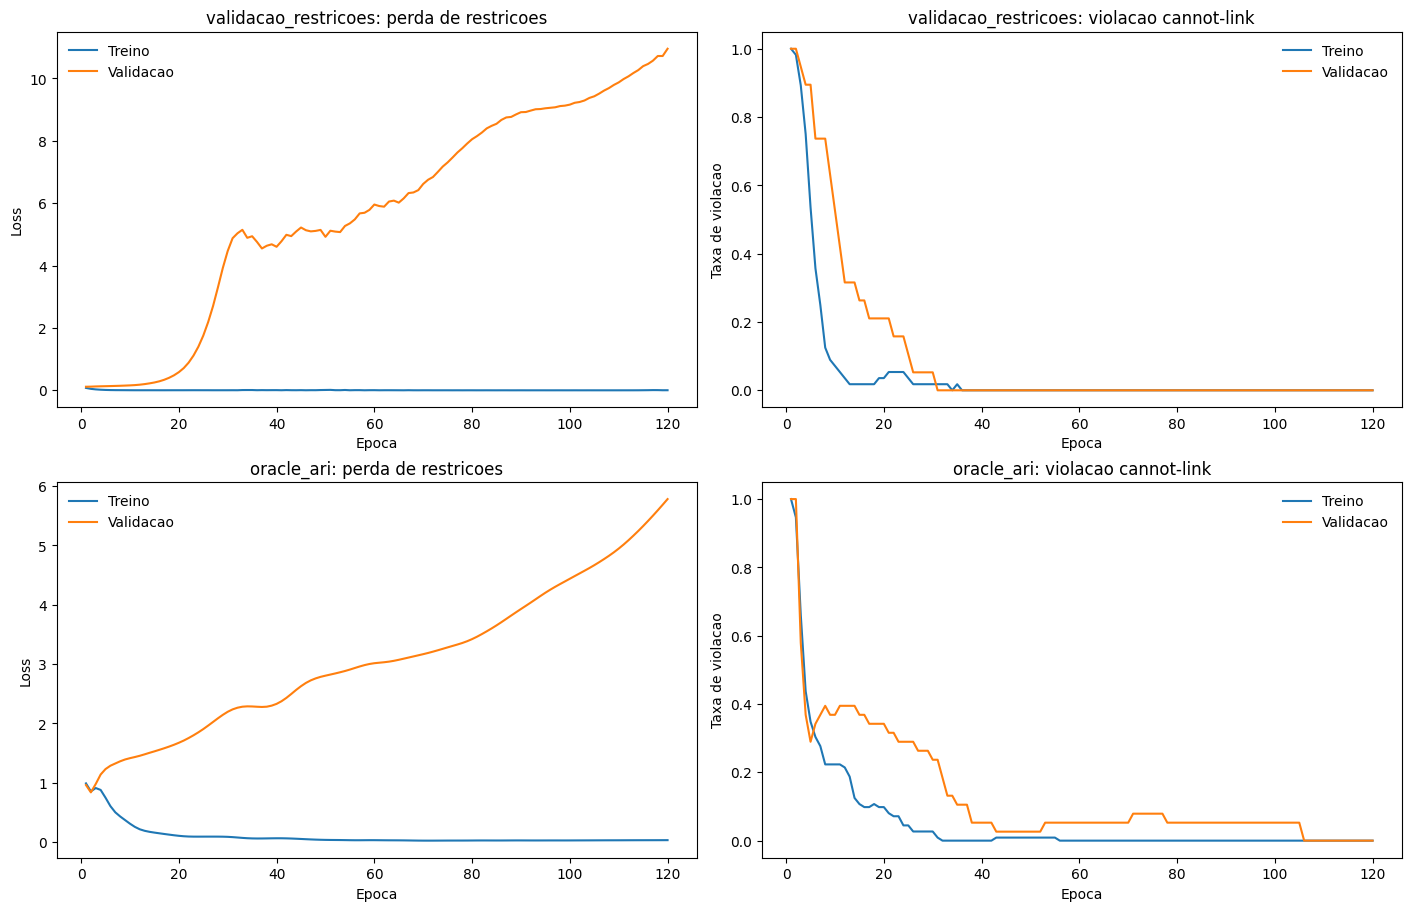

In [ ]:
def plot_train_validation_constraint_losses(diagnostics):
    selections = diagnostics["selection"].unique()
    fig, axes = plt.subplots(
        len(selections),
        2,
        figsize=(14, 4.5 * len(selections)),
        constrained_layout=True,
        squeeze=False,
    )

    for row_index, selection in enumerate(selections):
        selection_df = diagnostics[diagnostics["selection"] == selection]

        axes[row_index, 0].plot(
            selection_df["epoch"],
            selection_df["train_constraint_loss"],
            label="Treino",
        )
        axes[row_index, 0].plot(
            selection_df["epoch"],
            selection_df["validation_constraint_loss"],
            label="Validacao",
        )
        axes[row_index, 0].set_title(f"{selection}: perda de restricoes")
        axes[row_index, 0].set_xlabel("Epoca")
        axes[row_index, 0].set_ylabel("Loss")
        axes[row_index, 0].legend(frameon=False)

        axes[row_index, 1].plot(
            selection_df["epoch"],
            selection_df["train_cannot_link_violation_rate"],
            label="Treino",
        )
        axes[row_index, 1].plot(
            selection_df["epoch"],
            selection_df["validation_cannot_link_violation_rate"],
            label="Validacao",
        )
        axes[row_index, 1].set_title(f"{selection}: violacao cannot-link")
        axes[row_index, 1].set_xlabel("Epoca")
        axes[row_index, 1].set_ylabel("Taxa de violacao")
        axes[row_index, 1].legend(frameon=False)

    return fig


fig = plot_train_validation_constraint_losses(constraint_overfitting_diagnostics)
plt.show()

In [ ]:
def summarize_overfitting_gap(diagnostics):
    final_rows = diagnostics.sort_values("epoch").groupby("selection").tail(1).copy()
    final_rows["constraint_loss_gap"] = (
        final_rows["validation_constraint_loss"] - final_rows["train_constraint_loss"]
    )
    final_rows["cannot_link_violation_gap"] = (
        final_rows["validation_cannot_link_violation_rate"]
        - final_rows["train_cannot_link_violation_rate"]
    )
    return final_rows[[
        "selection", "scenario", "train_constraint_loss", "validation_constraint_loss",
        "constraint_loss_gap", "train_cannot_link_violation_rate",
        "validation_cannot_link_violation_rate", "cannot_link_violation_gap",
    ]]


summarize_overfitting_gap(constraint_overfitting_diagnostics)

,selection,scenario,train_constraint_loss,validation_constraint_loss,constraint_loss_gap,train_cannot_link_violation_rate,validation_cannot_link_violation_rate,cannot_link_violation_gap
119,validacao_restricoes,50ML_75CL,0.002852,10.948531,10.945679,0.0,0.0,0.0
239,oracle_ari,100ML_150CL,0.032389,5.782605,5.750217,0.0,0.0,0.0


In [ ]:
def best_validation_epoch_summary(diagnostics):
    rows = []
    for selection, selection_df in diagnostics.groupby("selection"):
        best_row = selection_df.sort_values("validation_constraint_loss").iloc[0]
        final_row = selection_df.sort_values("epoch").iloc[-1]
        rows.append({
            "selection": selection,
            "scenario": best_row["scenario"],
            "best_epoch": int(best_row["epoch"]),
            "best_validation_constraint_loss": float(best_row["validation_constraint_loss"]),
            "final_epoch": int(final_row["epoch"]),
            "final_validation_constraint_loss": float(final_row["validation_constraint_loss"]),
            "final_minus_best_validation_loss": float(
                final_row["validation_constraint_loss"] - best_row["validation_constraint_loss"]
            ),
            "best_train_constraint_loss": float(best_row["train_constraint_loss"]),
            "final_train_constraint_loss": float(final_row["train_constraint_loss"]),
        })

    return pd.DataFrame(rows).sort_values("best_validation_constraint_loss")


best_validation_epoch_summary(constraint_overfitting_diagnostics)


,selection,scenario,best_epoch,best_validation_constraint_loss,final_epoch,final_validation_constraint_loss,final_minus_best_validation_loss,best_train_constraint_loss,final_train_constraint_loss
1,validacao_restricoes,50ML_75CL,1,0.114965,120,10.948531,10.833566,0.076784,0.002852
0,oracle_ari,100ML_150CL,2,0.838098,120,5.782605,4.944508,0.854834,0.032389


### 7.8 Matrizes de contingencia entre clusters e tipos celulares

As metricas globais nao mostram quais tipos celulares estao sendo confundidos. As matrizes abaixo cruzam clusters e rotulos reais para os principais modelos.

In [ ]:
import matplotlib.pyplot as plt


def best_cop_scenario(cop_rows):
    cop_df = pd.DataFrame(cop_rows)
    best_row = cop_df.sort_values("ARI", ascending=False).iloc[0]
    return best_row["constraints"]


def best_semisupervised_key(semisupervised_results_df):
    best_row = semisupervised_results_df.sort_values("ARI", ascending=False).iloc[0]
    return best_row["constraints"], int(best_row["latent_dim"])


def cluster_label_contingency(y_true, cluster_labels, label_encoder):
    decoded_labels = label_encoder.inverse_transform(np.asarray(y_true))
    contingency = pd.crosstab(
        pd.Series(cluster_labels, name="cluster"),
        pd.Series(decoded_labels, name="cell_type"),
    )
    return contingency


best_cop_name = best_cop_scenario(cop_rows)
best_semisup_key = best_semisupervised_key(semisupervised_results_df)

contingency_tables = {
    "PCA + KMeans": cluster_label_contingency(y, pca_kmeans_result["labels"], prepared["label_encoder"]),
    f"COP-KMeans ({best_cop_name})": cluster_label_contingency(
        y,
        cop_results[best_cop_name]["labels"],
        prepared["label_encoder"],
    ),
    "AE nao supervisionado + KMeans": cluster_label_contingency(y, ae_labels, prepared["label_encoder"]),
    "AE semi-supervisionado - melhor ARI observado": cluster_label_contingency(
        y,
        semisupervised_results[best_semisup_key]["labels"],
        prepared["label_encoder"],
    ),
    "AE tunado - validacao restricoes": cluster_label_contingency(
        y,
        validation_selected_result["labels"],
        prepared["label_encoder"],
    ),
}

contingency_tables["AE tunado - validacao restricoes"]


cell_type,Bcell,Myeloid,Stromal,Tcell,Tumor
cluster,,,,,
0,50,2,0,16,1
1,33,22,1,31,15
2,0,0,0,0,71
3,0,12,19,4,98
4,0,2,3,3,132


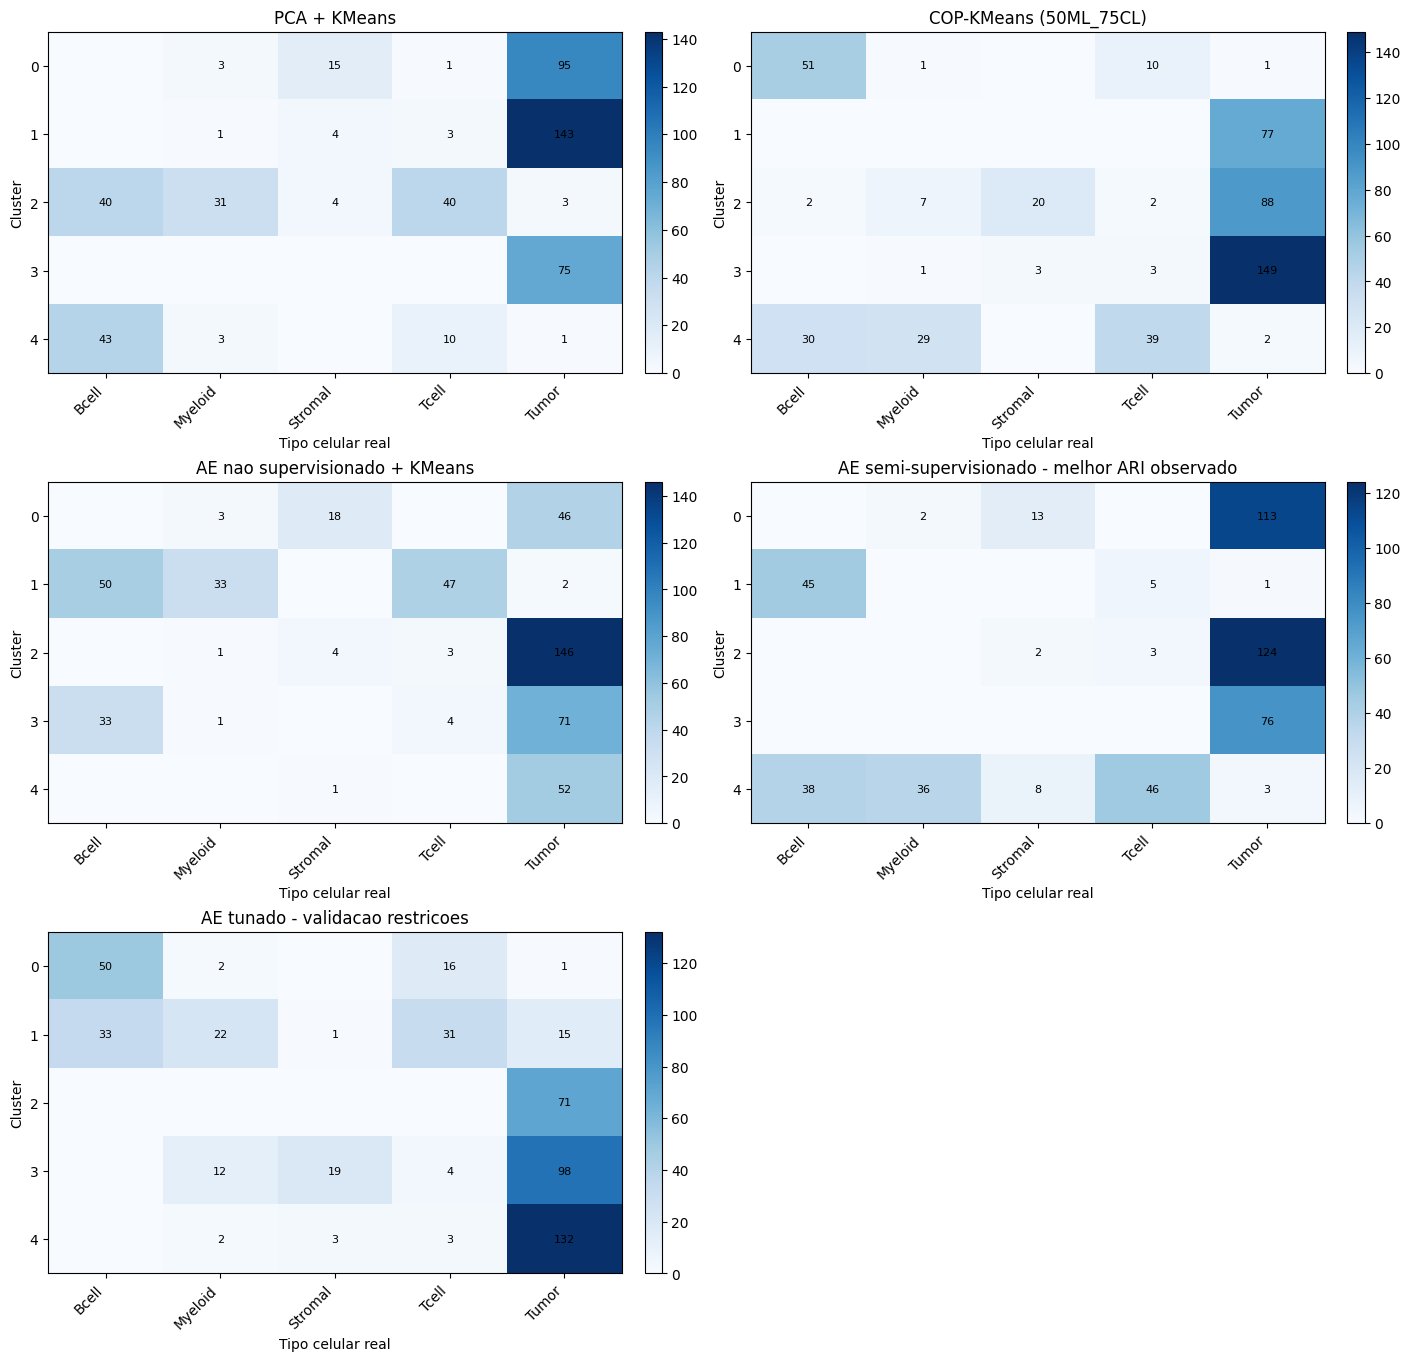

In [ ]:
def plot_contingency_heatmaps(contingency_tables):
    n_tables = len(contingency_tables)
    n_cols = 2
    n_rows = int(np.ceil(n_tables / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)

    for axis, (title, table) in zip(axes, contingency_tables.items()):
        image = axis.imshow(table.values, cmap="Blues", aspect="auto")
        axis.set_title(title)
        axis.set_xlabel("Tipo celular real")
        axis.set_ylabel("Cluster")
        axis.set_xticks(np.arange(table.shape[1]))
        axis.set_xticklabels(table.columns, rotation=45, ha="right")
        axis.set_yticks(np.arange(table.shape[0]))
        axis.set_yticklabels(table.index)
        for row_index in range(table.shape[0]):
            for col_index in range(table.shape[1]):
                value = int(table.values[row_index, col_index])
                if value > 0:
                    axis.text(col_index, row_index, str(value), ha="center", va="center", fontsize=8)
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

    for axis in axes[n_tables:]:
        axis.axis("off")

    return fig


fig = plot_contingency_heatmaps(contingency_tables)
plt.show()

### 7.9 Visualizacoes da escolha de hiperparametros

Os graficos abaixo ajudam a interpretar a busca. O criterio honesto de escolha e a perda de validacao das restricoes; o ARI aparece apenas como metrica externa de analise.

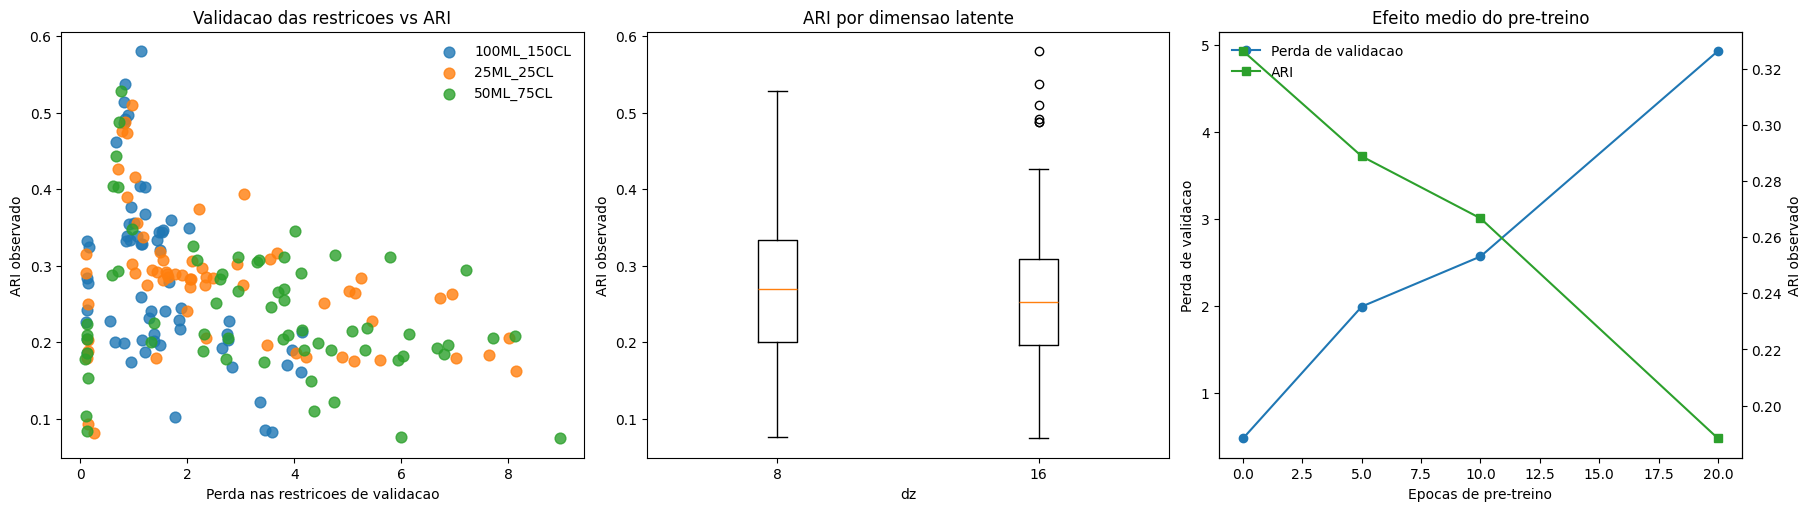

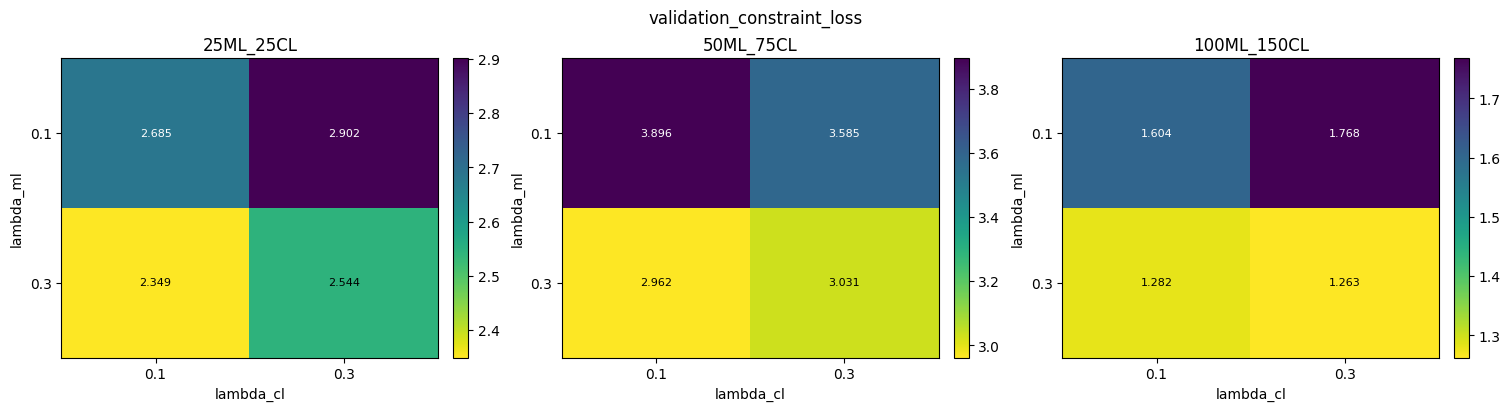

In [ ]:
def plot_tuning_search_overview(tuning_results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    for scenario_name, scenario_df in tuning_results.groupby("scenario"):
        axes[0].scatter(
            scenario_df["validation_constraint_loss"],
            scenario_df["ARI"],
            s=60,
            alpha=0.8,
            label=scenario_name,
        )
    axes[0].set_title("Validacao das restricoes vs ARI")
    axes[0].set_xlabel("Perda nas restricoes de validacao")
    axes[0].set_ylabel("ARI observado")
    axes[0].legend(frameon=False)

    latent_dims = sorted(tuning_results["latent_dim"].unique())
    ari_by_latent = [
        tuning_results.loc[tuning_results["latent_dim"] == latent_dim, "ARI"].to_numpy()
        for latent_dim in latent_dims
    ]
    axes[1].boxplot(ari_by_latent, tick_labels=[str(dim) for dim in latent_dims])
    axes[1].set_title("ARI por dimensao latente")
    axes[1].set_xlabel("dz")
    axes[1].set_ylabel("ARI observado")

    pretrain_summary = (
        tuning_results
        .groupby("pretrain_epochs", as_index=False)
        .agg(
            validation_constraint_loss=("validation_constraint_loss", "mean"),
            ARI=("ARI", "mean"),
        )
        .sort_values("pretrain_epochs")
    )
    axes[2].plot(
        pretrain_summary["pretrain_epochs"],
        pretrain_summary["validation_constraint_loss"],
        marker="o",
        label="Perda de validacao",
    )
    axes[2].set_title("Efeito medio do pre-treino")
    axes[2].set_xlabel("Epocas de pre-treino")
    axes[2].set_ylabel("Perda de validacao")
    axis_ari = axes[2].twinx()
    axis_ari.plot(
        pretrain_summary["pretrain_epochs"],
        pretrain_summary["ARI"],
        marker="s",
        color="tab:green",
        label="ARI",
    )
    axis_ari.set_ylabel("ARI observado")

    lines, labels = axes[2].get_legend_handles_labels()
    lines_ari, labels_ari = axis_ari.get_legend_handles_labels()
    axes[2].legend(lines + lines_ari, labels + labels_ari, frameon=False, loc="best")

    return fig


def plot_lambda_heatmaps(tuning_results, metric="validation_constraint_loss"):
    scenario_names = tuning_results["scenario"].unique()
    fig, axes = plt.subplots(
        1,
        len(scenario_names),
        figsize=(5 * len(scenario_names), 4),
        constrained_layout=True,
        squeeze=False,
    )
    axes = axes.reshape(-1)
    cmap = "viridis_r" if "loss" in metric else "viridis"

    for axis, scenario_name in zip(axes, scenario_names):
        scenario_df = tuning_results[tuning_results["scenario"] == scenario_name]
        pivot = scenario_df.pivot_table(
            index="lambda_ml",
            columns="lambda_cl",
            values=metric,
            aggfunc="mean",
        ).sort_index().sort_index(axis=1)

        image = axis.imshow(pivot.values, cmap=cmap, aspect="auto")
        axis.set_title(scenario_name)
        axis.set_xlabel("lambda_cl")
        axis.set_ylabel("lambda_ml")
        axis.set_xticks(np.arange(len(pivot.columns)))
        axis.set_xticklabels([str(value) for value in pivot.columns])
        axis.set_yticks(np.arange(len(pivot.index)))
        axis.set_yticklabels([str(value) for value in pivot.index])

        for row_index in range(pivot.shape[0]):
            for col_index in range(pivot.shape[1]):
                value = pivot.values[row_index, col_index]
                if np.isfinite(value):
                    axis.text(
                        col_index,
                        row_index,
                        f"{value:.3f}",
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="white" if value > np.nanmean(pivot.values) else "black",
                    )

        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

    fig.suptitle(metric)
    return fig


fig = plot_tuning_search_overview(tuning_results_df)
plt.show()

fig = plot_lambda_heatmaps(tuning_results_df, metric="validation_constraint_loss")
plt.show()

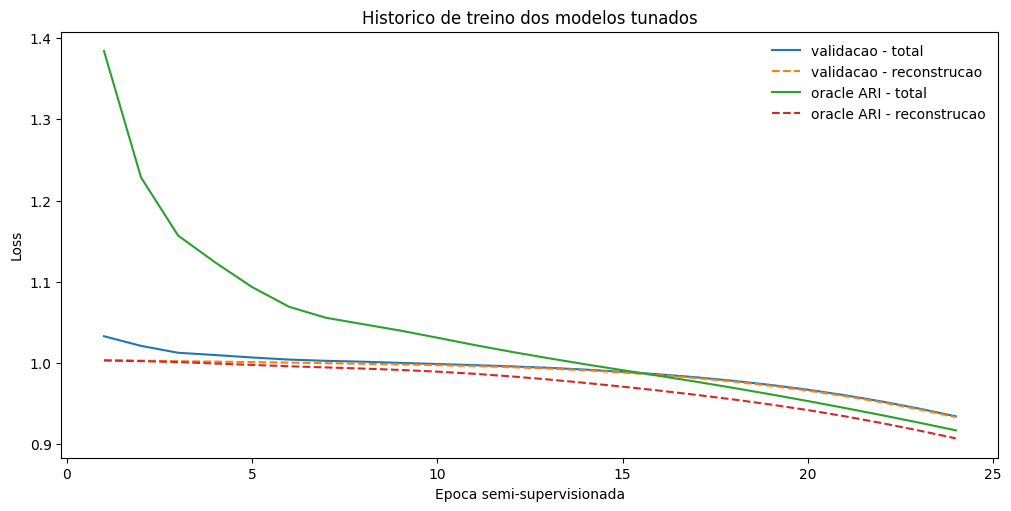

In [ ]:
def plot_best_tuned_training_history(selected_results):
    fig, axis = plt.subplots(figsize=(10, 5), constrained_layout=True)
    for label, result in selected_results.items():
        history = result["history"]
        semi_history = history[history["phase"].eq("semisupervised")] if "phase" in history else history
        axis.plot(semi_history["epoch"], semi_history["total_loss"], label=f"{label} - total")
        axis.plot(semi_history["epoch"], semi_history["reconstruction_loss"], linestyle="--", label=f"{label} - reconstrucao")
    axis.set_title("Historico de treino dos modelos tunados")
    axis.set_xlabel("Epoca semi-supervisionada")
    axis.set_ylabel("Loss")
    axis.legend(frameon=False)
    return fig


fig = plot_best_tuned_training_history({
    "validacao": validation_selected_result,
    "oracle ARI": oracle_ari_selected_result,
})
plt.show()

## 8. Visualizacoes bidimensionais

Esta secao usa t-SNE para comparar os agrupamentos. Primeiro, todos os modelos sao coloridos sobre a mesma projecao dos dados de entrada reduzidos por PCA. Depois, para corrigir uma limitacao metodologica importante, o t-SNE tambem e aplicado diretamente aos espacos latentes dos autoencoders.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


def make_tsne_embedding(X, n_pca_components=50, random_state=RANDOM_STATE):
    n_components = min(n_pca_components, X.shape[0] - 1, X.shape[1])
    X_reduced = PCA(n_components=n_components, random_state=random_state).fit_transform(X)
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    embedding_2d = tsne.fit_transform(X_reduced)
    return embedding_2d


def best_cop_scenario(cop_rows):
    cop_df = pd.DataFrame(cop_rows)
    best_row = cop_df.sort_values("ARI", ascending=False).iloc[0]
    return best_row["constraints"]


def best_semisupervised_key(semisupervised_results_df):
    best_row = semisupervised_results_df.sort_values("ARI", ascending=False).iloc[0]
    return best_row["constraints"], int(best_row["latent_dim"])


tsne_embedding = make_tsne_embedding(X)
best_cop_name = best_cop_scenario(cop_rows)
best_semisup_key = best_semisupervised_key(semisupervised_results_df)

plot_labels = {
    "Rotulo real": prepared["label_encoder"].inverse_transform(y),
    "PCA + KMeans": pca_kmeans_result["labels"],
    f"COP-KMeans ({best_cop_name})": cop_results[best_cop_name]["labels"],
    "AE nao supervisionado + KMeans": ae_labels,
    f"AE semisup - melhor ARI observado ({best_semisup_key[0]}, dz={best_semisup_key[1]})": semisupervised_results[best_semisup_key]["labels"],
    "AE tunado - validacao restricoes": validation_selected_result["labels"],
}

best_cop_name, best_semisup_key

('50ML_75CL', ('25ML_25CL', 16))

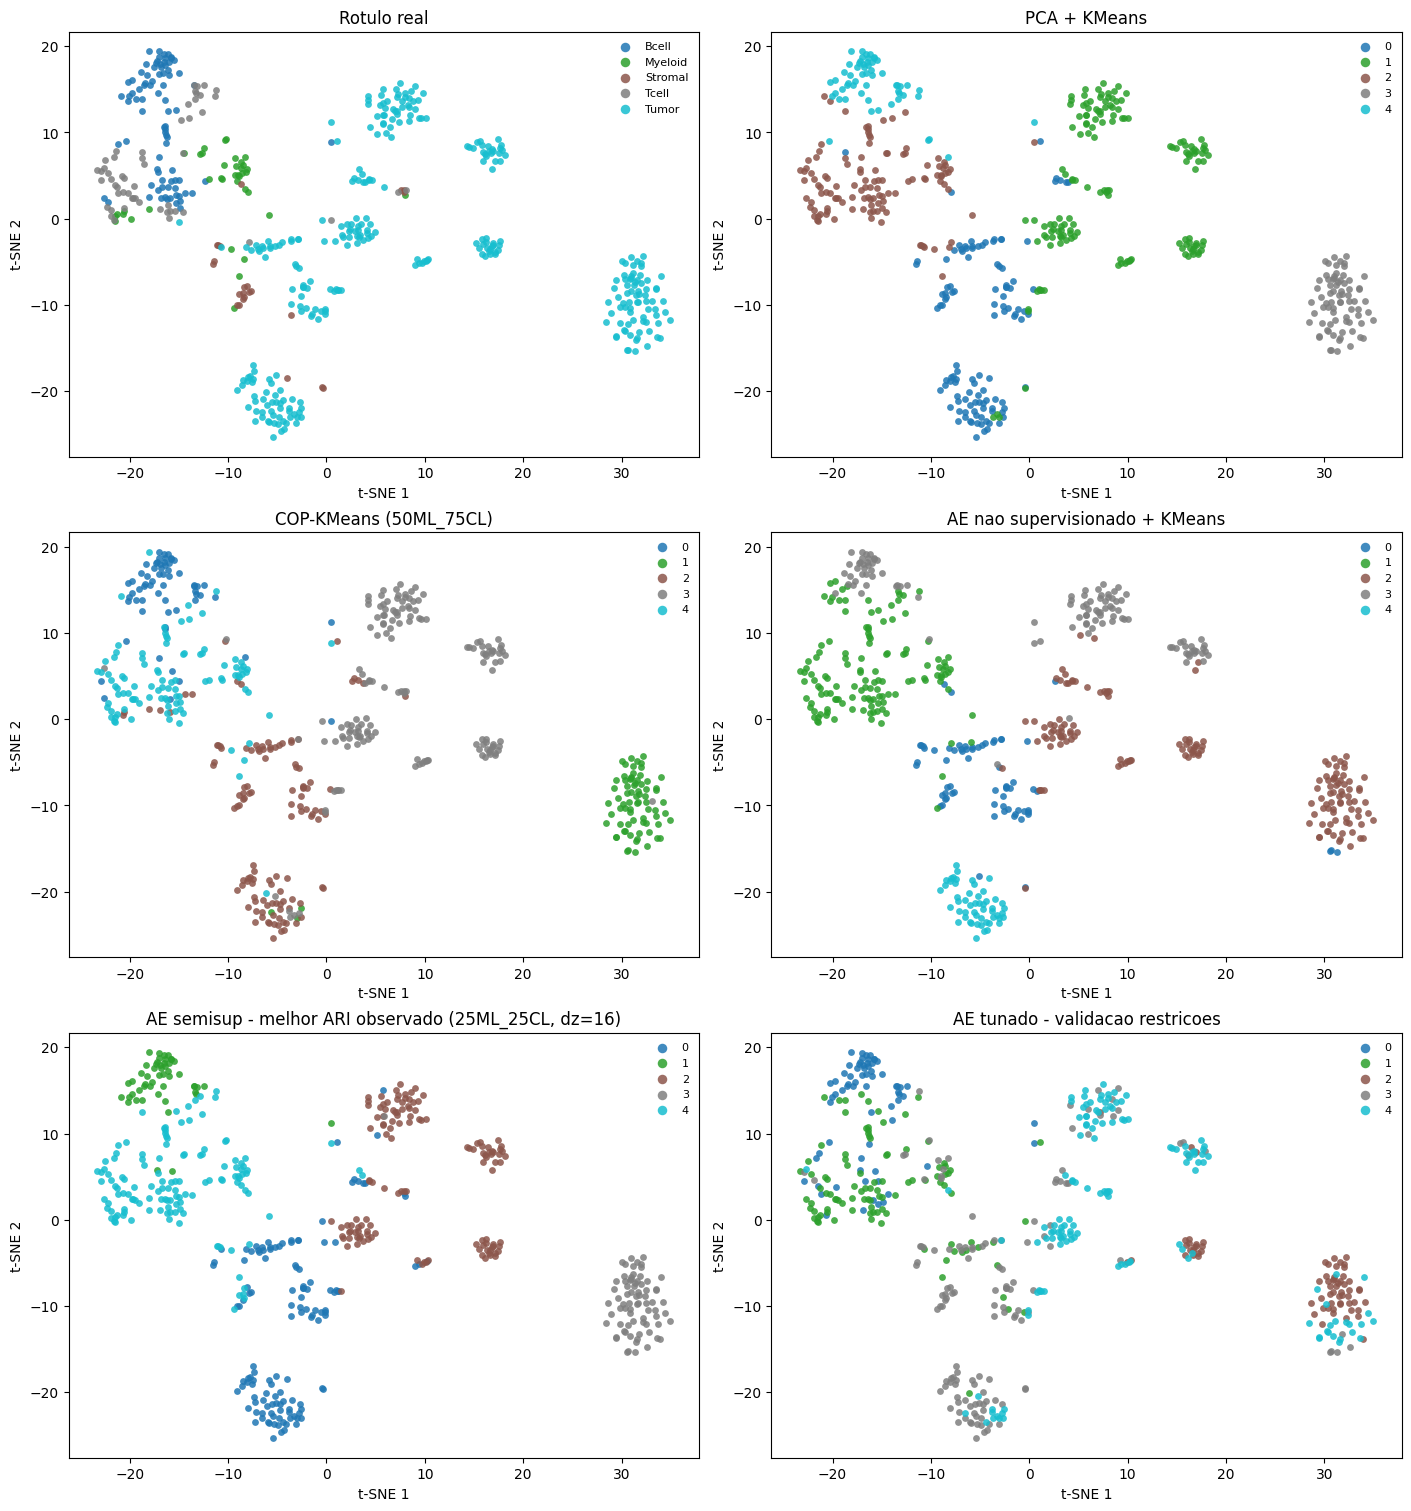

In [ ]:
def plot_embedding_by_labels(embedding_2d, labels_by_plot, point_size=24, alpha=0.85):
    n_plots = len(labels_by_plot)
    n_cols = 2
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows), constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)

    for axis, (title, labels) in zip(axes, labels_by_plot.items()):
        labels = np.asarray(labels)
        unique_labels = np.unique(labels)
        color_map = plt.colormaps["tab10"].resampled(len(unique_labels))

        for color_index, label in enumerate(unique_labels):
            mask = labels == label
            axis.scatter(
                embedding_2d[mask, 0],
                embedding_2d[mask, 1],
                s=point_size,
                alpha=alpha,
                color=color_map(color_index),
                label=str(label),
                linewidths=0,
            )

        axis.set_title(title)
        axis.set_xlabel("t-SNE 1")
        axis.set_ylabel("t-SNE 2")
        axis.legend(markerscale=1.4, fontsize=8, frameon=False)

    for axis in axes[n_plots:]:
        axis.axis("off")

    return fig


fig = plot_embedding_by_labels(tsne_embedding, plot_labels)
plt.show()

### 8.1 Visualizacoes separadas por modelo

A figura anterior mostra tudo em grade. As celulas abaixo tambem deixam cada visualizacao disponivel separadamente caso seja melhor para o relatorio final.

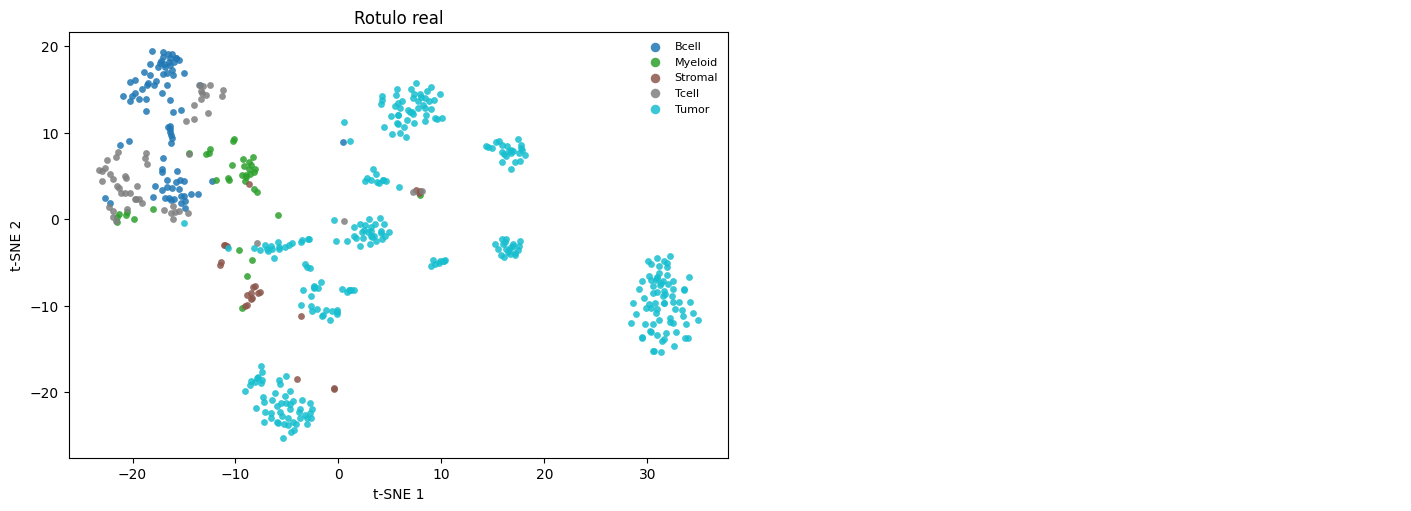

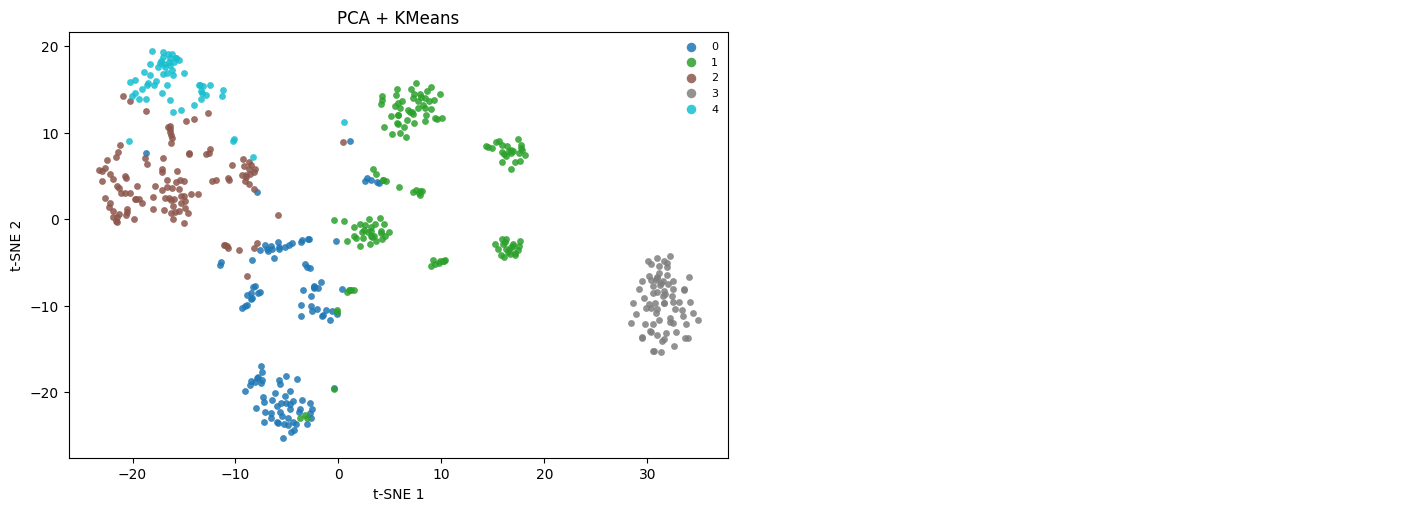

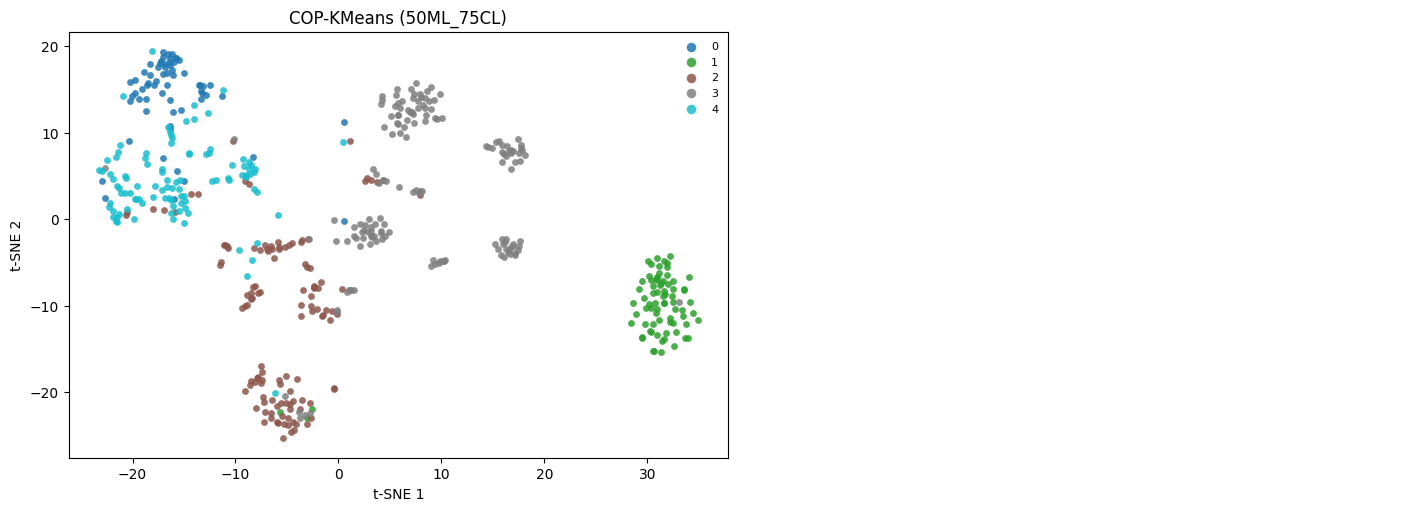

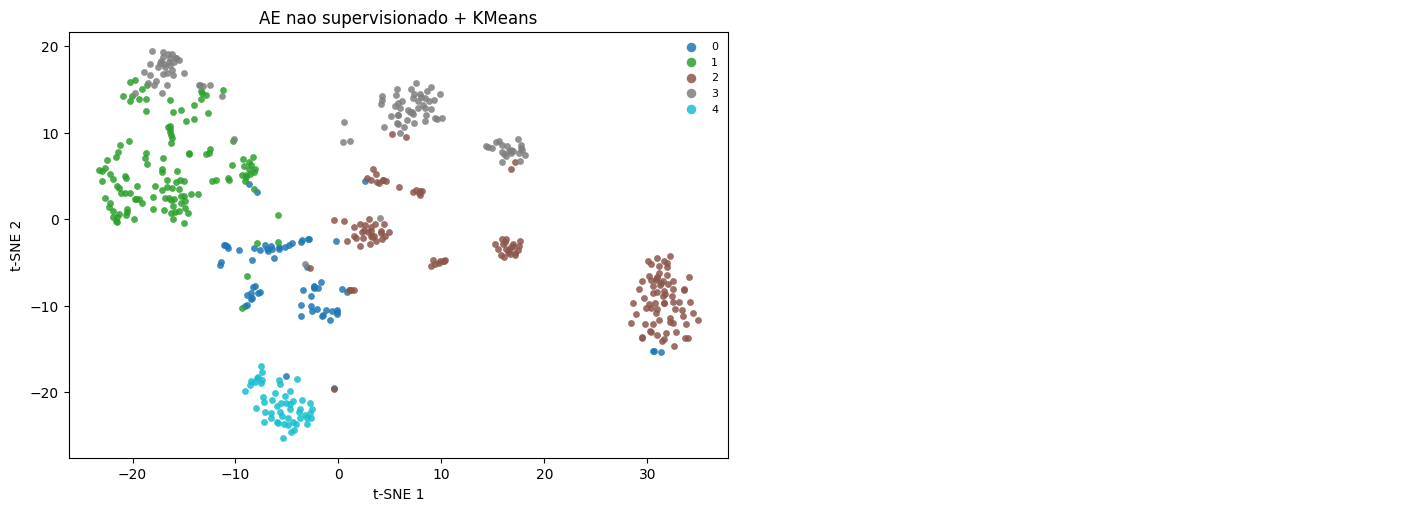

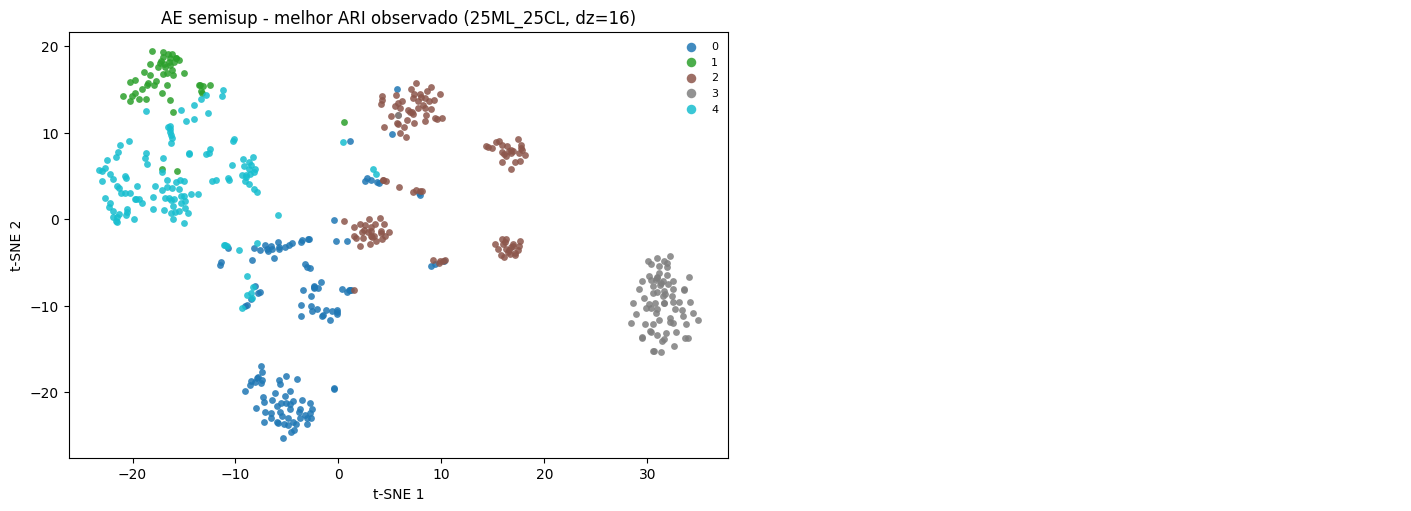

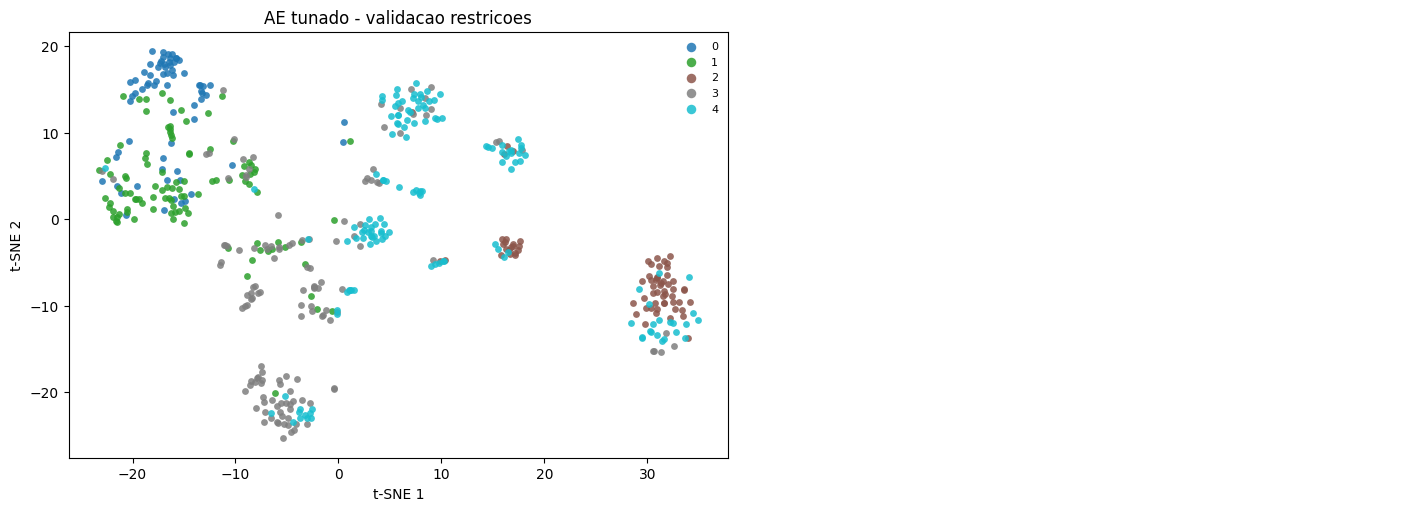

In [ ]:
for title, labels in plot_labels.items():
    fig = plot_embedding_by_labels(tsne_embedding, {title: labels})
    plt.show()

### 8.2 Visualizacoes diretas dos espacos latentes

As figuras anteriores usam uma mesma projecao dos dados de entrada para todos os modelos. As figuras abaixo projetam diretamente os vetores latentes dos autoencoders, o que permite avaliar melhor se o espaco aprendido ficou mais organizado.

Importante: os identificadores de cluster (`0`, `1`, `2`, etc.) sao arbitrarios e nao correspondem diretamente aos tipos celulares. Para evitar uma leitura enganosa, a visualizacao abaixo mapeia cada cluster para o tipo celular majoritario dentro dele e usa a mesma paleta dos rotulos reais. A geometria do t-SNE tambem nao deve ser comparada entre linhas diferentes, pois cada modelo tem sua propria projecao.

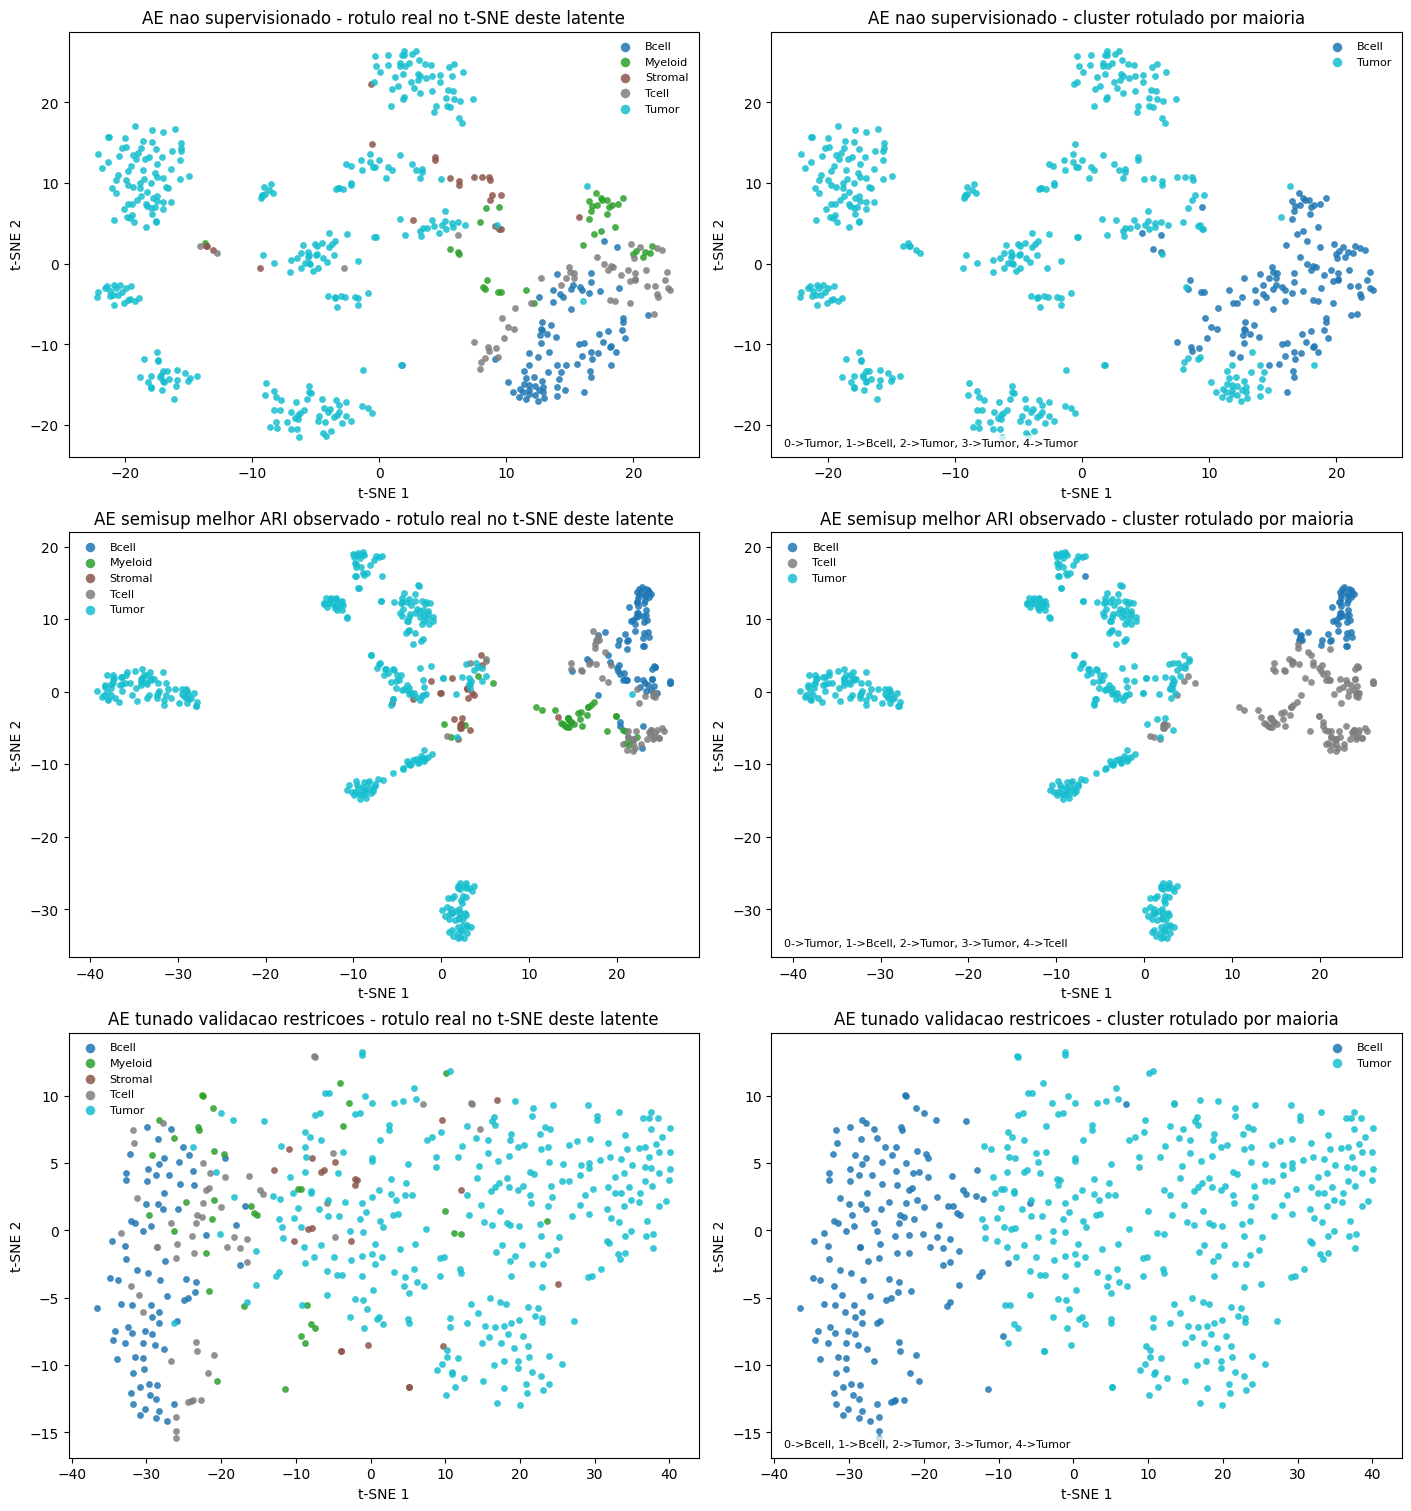

In [ ]:
def map_clusters_to_majority_labels(y_true, cluster_labels, label_encoder):
    decoded_labels = label_encoder.inverse_transform(np.asarray(y_true))
    cluster_labels = np.asarray(cluster_labels)
    mapped_labels = np.empty(cluster_labels.shape, dtype=object)
    cluster_to_majority_label = {}

    for cluster in np.unique(cluster_labels):
        mask = cluster_labels == cluster
        majority_label = pd.Series(decoded_labels[mask]).value_counts().idxmax()
        cluster_to_majority_label[cluster] = majority_label
        mapped_labels[mask] = majority_label

    return mapped_labels, cluster_to_majority_label


def plot_cell_type_labels(axis, embedding_2d, labels, class_names, color_by_class, title):
    labels = np.asarray(labels)
    for class_name in class_names:
        mask = labels == class_name
        if not np.any(mask):
            continue
        axis.scatter(
            embedding_2d[mask, 0],
            embedding_2d[mask, 1],
            s=24,
            alpha=0.85,
            color=color_by_class[class_name],
            label=str(class_name),
            linewidths=0,
        )
    axis.set_title(title)
    axis.set_xlabel("t-SNE 1")
    axis.set_ylabel("t-SNE 2")
    axis.legend(markerscale=1.4, fontsize=8, frameon=False)


def plot_latent_space_by_model(latent_by_model, y, labels_by_model, label_encoder, random_state=RANDOM_STATE):
    decoded_labels = label_encoder.inverse_transform(y)
    class_names = label_encoder.classes_.tolist()
    color_map = plt.colormaps["tab10"].resampled(len(class_names))
    color_by_class = {
        class_name: color_map(class_index)
        for class_index, class_name in enumerate(class_names)
    }

    n_models = len(latent_by_model)
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models), constrained_layout=True)
    axes = np.asarray(axes).reshape(n_models, 2)

    for row_index, (model_name, latent) in enumerate(latent_by_model.items()):
        embedding = make_tsne_embedding(
            latent,
            n_pca_components=min(50, latent.shape[1]),
            random_state=random_state + row_index,
        )
        mapped_cluster_labels, cluster_mapping = map_clusters_to_majority_labels(
            y,
            labels_by_model[model_name],
            label_encoder,
        )

        plot_cell_type_labels(
            axes[row_index, 0],
            embedding,
            decoded_labels,
            class_names,
            color_by_class,
            f"{model_name} - rotulo real no t-SNE deste latente",
        )
        plot_cell_type_labels(
            axes[row_index, 1],
            embedding,
            mapped_cluster_labels,
            class_names,
            color_by_class,
            f"{model_name} - cluster rotulado por maioria",
        )
        axes[row_index, 1].text(
            0.02,
            0.02,
            ", ".join(f"{cluster}->{label}" for cluster, label in sorted(cluster_mapping.items())),
            transform=axes[row_index, 1].transAxes,
            fontsize=8,
            va="bottom",
            ha="left",
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )

    return fig


latent_by_model = {
    "AE nao supervisionado": ae_latent,
    "AE semisup melhor ARI observado": semisupervised_results[best_semisup_key]["latent"],
    "AE tunado validacao restricoes": validation_selected_result["latent"],
}

latent_labels_by_model = {
    "AE nao supervisionado": ae_labels,
    "AE semisup melhor ARI observado": semisupervised_results[best_semisup_key]["labels"],
    "AE tunado validacao restricoes": validation_selected_result["labels"],
}

fig = plot_latent_space_by_model(
    latent_by_model,
    y,
    latent_labels_by_model,
    prepared["label_encoder"],
)
plt.show()

### 8.3 Matrizes normalizadas por tipo celular

As matrizes abaixo mostram, para cada tipo celular real, como suas celulas foram distribuidas entre os clusters. Cada coluna soma 100%. Esta representacao e mais direta do que t-SNE para identificar quando uma classe pequena nao virou classe majoritaria em nenhum cluster, mas ainda aparece misturada dentro de clusters dominados por outros tipos celulares.

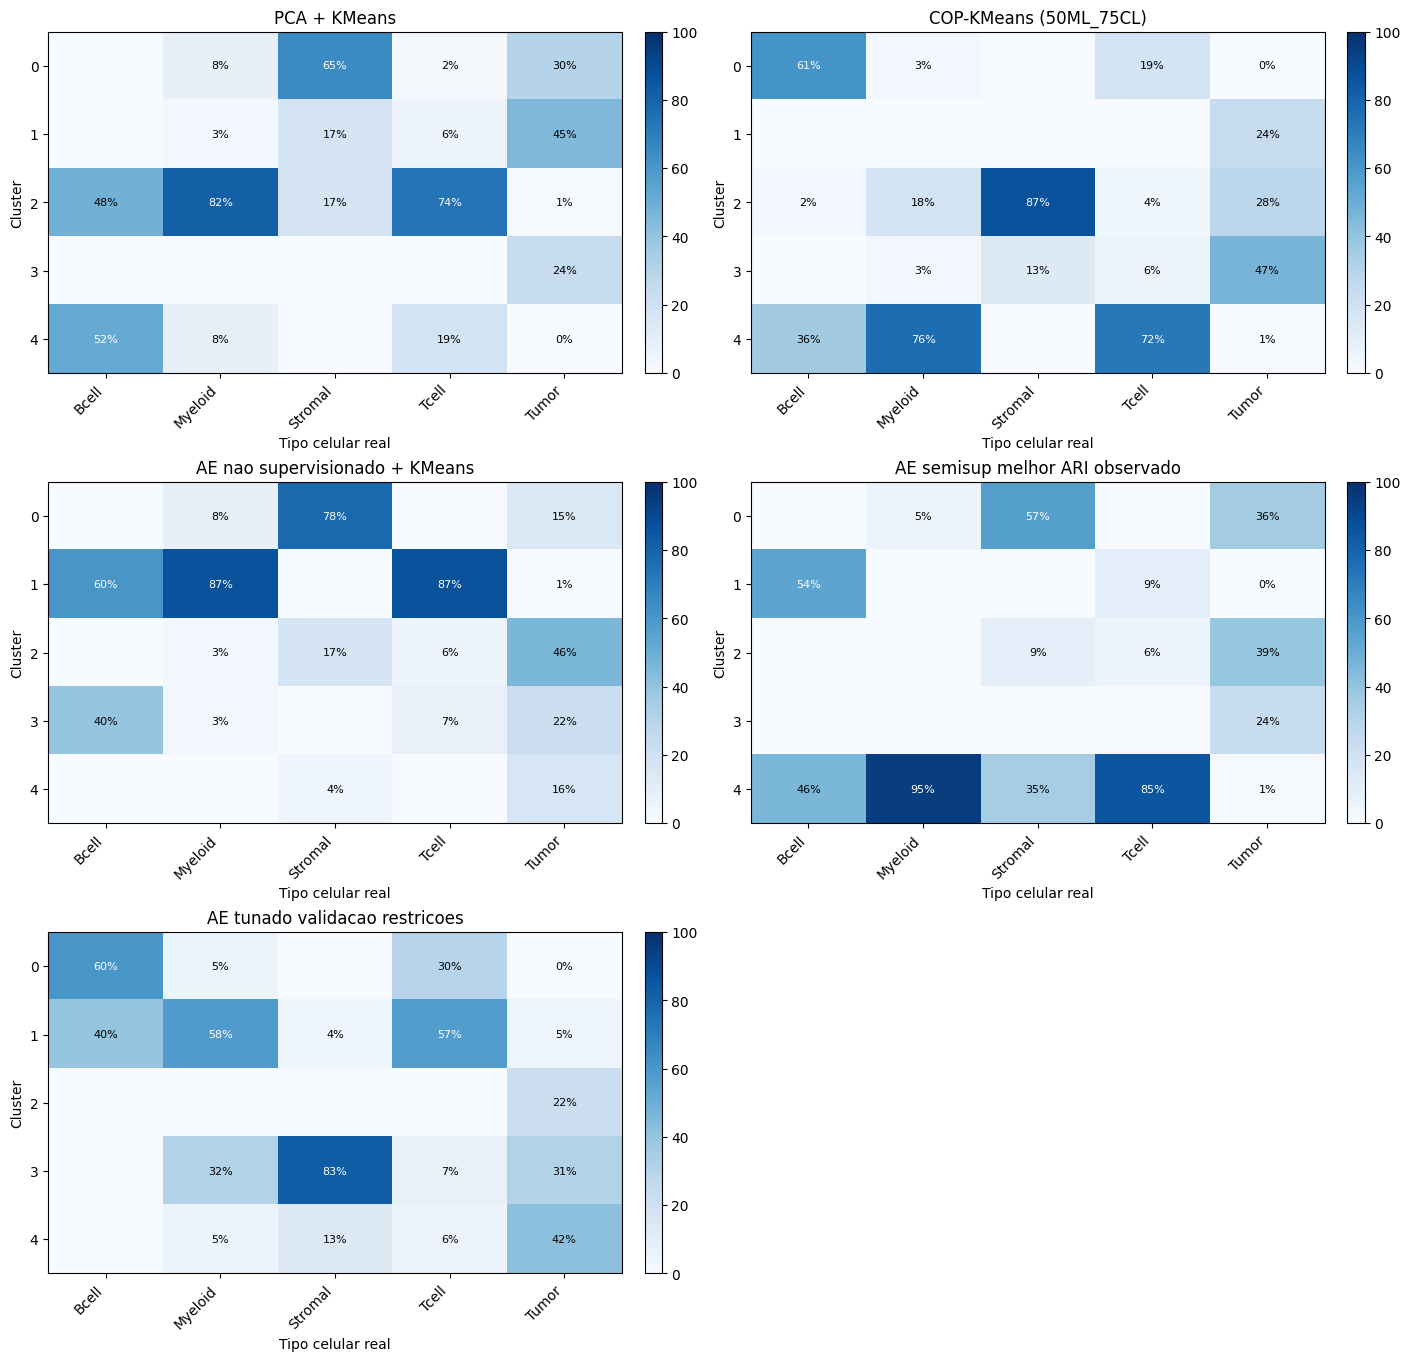

cell_type,Bcell,Myeloid,Stromal,Tcell,Tumor
cluster,,,,,
0,60.240964,5.263158,0.000000,29.629630,0.315457
1,39.759036,57.894737,4.347826,57.407407,4.731861
2,0.000000,0.000000,0.000000,0.000000,22.397476
3,0.000000,31.578947,82.608696,7.407407,30.914826
4,0.000000,5.263158,13.043478,5.555556,41.640379


In [ ]:
def normalized_cluster_label_contingency(y_true, cluster_labels, label_encoder):
    contingency = cluster_label_contingency(y_true, cluster_labels, label_encoder)
    column_totals = contingency.sum(axis=0).replace(0, np.nan)
    return contingency.div(column_totals, axis=1).mul(100).fillna(0.0)


def plot_normalized_contingency_heatmaps(contingency_tables):
    n_tables = len(contingency_tables)
    n_cols = 2
    n_rows = int(np.ceil(n_tables / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)

    for axis, (title, table) in zip(axes, contingency_tables.items()):
        image = axis.imshow(table.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)
        axis.set_title(title)
        axis.set_xlabel("Tipo celular real")
        axis.set_ylabel("Cluster")
        axis.set_xticks(np.arange(table.shape[1]))
        axis.set_xticklabels(table.columns, rotation=45, ha="right")
        axis.set_yticks(np.arange(table.shape[0]))
        axis.set_yticklabels(table.index)
        for row_index in range(table.shape[0]):
            for col_index in range(table.shape[1]):
                value = table.values[row_index, col_index]
                if value > 0:
                    axis.text(
                        col_index,
                        row_index,
                        f"{value:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="white" if value >= 50 else "black",
                    )
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

    for axis in axes[n_tables:]:
        axis.axis("off")

    return fig


normalized_contingency_tables = {
    model_name: normalized_cluster_label_contingency(y, labels, prepared["label_encoder"])
    for model_name, labels in {
        "PCA + KMeans": pca_kmeans_result["labels"],
        f"COP-KMeans ({best_cop_name})": cop_results[best_cop_name]["labels"],
        "AE nao supervisionado + KMeans": ae_labels,
        "AE semisup melhor ARI observado": semisupervised_results[best_semisup_key]["labels"],
        "AE tunado validacao restricoes": validation_selected_result["labels"],
    }.items()
}

fig = plot_normalized_contingency_heatmaps(normalized_contingency_tables)
plt.show()

normalized_contingency_tables["AE tunado validacao restricoes"]


#9. Discussão crítica e conclusão

O notebook implementa o escopo central proposto: preparação do GSE75688, geração limitada de restrições must-link e cannot-link, comparação entre PCA + KMeans, COP-KMeans, autoencoder não supervisionado e autoencoder semi-supervisionado com perdas par-a-par. A amostra efetiva usada nos modelos possui 515 células, e não 549, pois foram mantidas apenas células single-cell presentes simultaneamente na matriz de expressão e nos metadados, com rótulo válido na coluna index3.

Uma decisão metodológica importante foi usar amostragem estratificada das restrições. Como a classe Tumor é majoritária, uma amostragem puramente aleatória poderia concentrar muitos pares nessa classe. A estratificação torna o conhecimento parcial mais equilibrado, permitindo que classes menores também influenciem o agrupamento. Ainda assim, os resultados devem ser interpretados como um estudo controlado com conhecimento parcial, não como uma situação totalmente sem anotações.

A seleção dos modelos foi analisada em duas camadas. A primeira, metodologicamente mais honesta, escolhe hiperparâmetros pela perda em restrições de validação, sem usar diretamente as métricas finais baseadas nos rótulos reais. A segunda, chamada de seleção oracular por ARI, mostra o melhor resultado observado quando os rótulos completos são usados apenas para análise posterior. Essa segunda seleção é útil como referência otimista, mas não deve ser tratada como critério principal de escolha.

O uso de early stopping também fortalece a avaliação. O diagnóstico de overfitting mostrou que, em alguns casos, a perda nas restrições de treino continuava caindo enquanto a perda nas restrições de validação piorava. Com early stopping e restauração do melhor checkpoint, reduz-se o risco de reportar um modelo ajustado excessivamente aos pares observados.

Os resultados indicam que as restrições par-a-par podem melhorar a organização dos agrupamentos em algumas métricas, como NMI e Homogeneity. No entanto, o ganho em ARI não é garantido e pode não superar de forma robusta o COP-KMeans. Por isso, a interpretação principal não deve ser que o autoencoder semi-supervisionado vence todos os baselines, mas sim que ele implementa corretamente o uso de conhecimento parcial e mostra ganhos sob determinadas configurações.

As matrizes de contingência complementam as métricas quantitativas ao mostrar quais tipos celulares continuam sendo confundidos. As visualizações t-SNE também ajudam a interpretar a estrutura dos agrupamentos e dos espaços latentes aprendidos. No entanto, essas visualizações devem ser tratadas como ferramentas exploratórias, não como substitutas das métricas quantitativas.

O trabalho ainda apresenta limitações. O número de clusters foi definido a partir do número de rótulos conhecidos, o que é aceitável para uma avaliação controlada, mas não corresponderia necessariamente a um cenário real sem anotações. Além disso, a implementação de COP-KMeans é própria e poderia ser validada futuramente contra uma implementação externa. Também seria interessante repetir a amostragem das restrições, testar perdas contrastivas mais sofisticadas, variar estratégias de normalização do espaço latente, experimentar outros algoritmos de agrupamento e realizar análise biológica com genes marcadores por cluster.

Em síntese, o trabalho atende ao objetivo do tema como estudo exploratório. A hipótese de que restrições biológicas parciais podem ajudar o aprendizado de representações latentes encontra suporte parcial nos resultados, mas os ganhos dependem da quantidade e qualidade das restrições, da configuração do modelo e da estabilidade entre sementes. Portanto, a contribuição principal está em demonstrar uma implementação funcional e criticamente avaliada de agrupamento profundo semi-supervisionado para dados scRNA-seq.